Self Assessment Tool for Rehabilitation and TUG analysis
---
---
In this notebook, we explore the use of wearable IMU devices to create a self assessment system for rehabilitation and TUG analysis.  The devices are worn around the waist, around the knee and around the thigh.  
Each device records accelerometer and gyroscope measurements, as well as the arduino onboard clock timestamp (when the data was recorded). Each device has slight variations in the arduino milliseconds recorded.

#### The different Approaches 
---

To achieve our aim, we will experiment with different variations of our dataset, and different experimental approaches. Our resulting model will be a combination of the best performing dataset and approach combination. 

Because the timestamps from each IMU device is different, we will take different approaches to consolidate all the recorded measurements into a usable dataset

In the first approach, we will merge the data from each node into a dataset, using the average of the `pc_timestamp` field for each row. 

In the second approach, we will use each IMU device independently, flatten them and use them in building the models 

#### Imports, Constants and Utility Functions
---

In [1]:
# ============================================================================
# Core Data Science & File Utilities -----------------------------------------
# ============================================================================
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats
from scipy.signal import find_peaks

# ============================================================================
# Data Visualization ---------------------------------------------------------
# ============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
# Scikit-Learn ---------------------------------------------------------------
# ============================================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler,
)

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

# ============================================================================
# TensorFlow / Keras ---------------------------------------------------------
# ============================================================================
import tensorflow as tf

from tensorflow.keras.layers import (
    Conv1D,
    Dense,
    Dropout,
    Flatten,
    LSTM,
    MaxPooling1D,
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical

random_seed = 42

sns.set_theme(style="whitegrid")

current_dir = Path.cwd()
DATA_DIR = current_dir / 'data'
ORIGINAL_WISDM = DATA_DIR / 'WISDM_ar_v1.1_raw.csv'

def print_horizontal_line():
    print('-- -- -- -- ' * 50 )
    return

def run_pipeline(Dataset_A):
    return
    

#### GLobal Configurations
---


In [2]:
# ============================================================================
# GLOBAL HAR CONFIGURATION
# ============================================================================

RANDOM_SEED = 42

# ---------------------------------------------------------------------------
# SAMPLING CONFIGURATION
# ---------------------------------------------------------------------------

SAMPLING_RATE_HZ = 20

# Time interval between consecutive samples
DT = 1.0 / SAMPLING_RATE_HZ

# HAR window configuration
WINDOW_SECONDS = 5.0

# At 20 Hz:
# 5 seconds × 20 samples/second = 100 samples
TIME_STEPS = int(WINDOW_SECONDS * SAMPLING_RATE_HZ)

# 50% overlap
OVERLAP_RATIO = 0.50

# At 100 samples, hop size = 50 samples
HOP_SIZE = int(TIME_STEPS * (1 - OVERLAP_RATIO))

# User Data to Sample
SAMPLE_USER = 3

print("HAR Configuration")
print("-" * 50)
print(f"Sampling Rate : {SAMPLING_RATE_HZ} Hz")
print(f"Time Interval : {DT:.3f} seconds")
print(f"Window Length : {WINDOW_SECONDS} seconds")
print(f"Time Steps    : {TIME_STEPS} samples")
print(f"Hop Size      : {HOP_SIZE} samples")

HAR Configuration
--------------------------------------------------
Sampling Rate : 20 Hz
Time Interval : 0.050 seconds
Window Length : 5.0 seconds
Time Steps    : 100 samples
Hop Size      : 50 samples


#### Visualising the data folder structure
---

In [3]:
from pathlib import Path

def print_project_tree(directory: Path, prefix: str = "", ignore_hidden: bool = False):
    """Recursively prints a visual tree structure of a directory."""
    entries = sorted(list(directory.iterdir()), key=lambda e: (e.is_file(), e.name.lower()))
    
    if ignore_hidden:
        entries = [e for e in entries if not e.name.startswith('.')]

    count = len(entries)
    for index, entry in enumerate(entries):
        is_last = (index == count - 1)
        connector = "└── " if is_last else "├── "
        
        print(f"{prefix}{connector}{entry.name}{'/' if entry.is_dir() else ''}")
        
        if entry.is_dir():
            extension = "    " if is_last else "│   "
            print_project_tree(entry, prefix=prefix + extension, ignore_hidden=ignore_hidden)

if __name__ == "__main__":
    # Point this to your project folder path (e.g., Path("."))
    data_folder = Path("./data") 
    print(f"{data_folder.resolve().name}/")
    print_project_tree(data_folder, ignore_hidden=True)

data/
├── user_1/
│   ├── sit/
│   │   ├── session-knee.csv
│   │   ├── session-lumbar.csv
│   │   └── session-thigh.csv
│   ├── stand/
│   │   ├── session-knee.csv
│   │   ├── session-lumbar.csv
│   │   └── session-thigh.csv
│   ├── tug/
│   │   ├── session-knee.csv
│   │   ├── session-lumbar.csv
│   │   └── session-thigh.csv
│   └── walk/
│       ├── session-knee.csv
│       ├── session-lumbar.csv
│       └── session-thigh.csv
├── user_2/
│   ├── sit/
│   │   ├── session-knee.csv
│   │   ├── session-lumbar.csv
│   │   └── session-thigh.csv
│   ├── stand/
│   │   ├── session-knee.csv
│   │   ├── session-lumbar.csv
│   │   └── session-thigh.csv
│   ├── tug/
│   │   ├── session-knee.csv
│   │   ├── session-lumbar.csv
│   │   └── session-thigh.csv
│   ├── tug_2/
│   │   ├── session-knee.csv
│   │   ├── session-lumbar.csv
│   │   └── session-thigh.csv
│   ├── tug_4/
│   │   ├── session-knee.csv
│   │   ├── session-lumbar.csv
│   │   └── session-thigh.csv
│   ├── walk_2/
│   │   ├── sessio

---
#### The DataSet
---
Each IMU device measures and records the following fields: 
| Field Name | Description |
| :--- | :--- |
| `pc_timestamp` | The absolute wall-clock timestamp recorded by the receiving computer/server when the data packet was received. |
| `arduiono_ms` | The relative uptime timestamp in milliseconds (`millis()`) recorded by the Arduino microcontroller at the exact time of sample capture. |
| `node_position` | The physical location or placement of the sensor node on the subject's body (e.g., wrist, waist, thigh). |
| `activity` | The ground-truth physical activity label being performed during data collection (e.g., sitting, standing, walking). |
| `ax` | Acceleration along the spatial $X$-axis measured by the accelerometer. |
| `ay` | Acceleration along the spatial $Y$-axis measured by the accelerometer. |
| `az` | Acceleration along the spatial $Z$-axis measured by the accelerometer. |
| `gx` | Angular velocity (rotational speed) around the spatial $X$-axis measured by the gyroscope. |
| `gy` | Angular velocity (rotational speed) around the spatial $Y$-axis measured by the gyroscope. |
| `gz` | Angular velocity (rotational speed) around the spatial $Z$-axis measured by the gyroscope. |
| `rssi` | Received Signal Strength Indicator (typically in dBm), measuring the wireless signal quality between the IMU node and the receiver. |


Building the datasets: There will be two datasets, in `Dataset A`, all the columns in the different datasets will be merged, using the `pc_timestamp`
For each user, the three different sensors will be merged into one dataset for each activity. 

so, for `user_1` where activity is sit, the knee, lumbar and thigh datasets will be merged into one.

In [4]:

Dataset_A = pd.DataFrame()  # Initialize an empty DataFrame to hold the merged dataset


# load Dataset_A.csv if it already exists
if Path("Dataset_A.csv").exists():
    Dataset_A = pd.read_csv("Dataset_A.csv")
    print(f"Loaded existing Dataset_A.csv with shape: {Dataset_A.shape}")   

# Handle path whether running from project root or inside the 'notebooks/' directory
data_folder = Path("../data") if Path("../data").exists() else Path("data")

def load_and_prep_sensor(file_path: Path, node_label: str, join_key: str = "pc_timestamp") -> pd.DataFrame:
    " ""Reads CSV, parses timestamps, sorts chronologically, and prefixes feature columns."""
    df = pd.read_csv(file_path)
    
    # Convert timestamp column to datetime
    df[join_key] = pd.to_datetime(df[join_key])
    
    # Sort by timestamp required for pd.merge_asof
    df = df.sort_values(by=join_key).reset_index(drop=True)
    
    # Prefix feature columns with node label (e.g., knee_ax) to avoid column collisions
    rename_dict = {col: f"{node_label}_{col}" for col in df.columns if col != join_key}
    return df.rename(columns=rename_dict)

all_session_dfs = []

# Aggregate metrics trackers
metrics = {
    "knee_raw": 0,
    "lumbar_raw": 0,
    "thigh_raw": 0,
    "lumbar_mismatches": 0,
    "thigh_mismatches": 0,
    "final_rows": 0
}

# Create a formatted table header to keep session metrics
print(f"{'Session':<22} | {'Knee':<6} | {'Lumbar':<6} | {'Thigh':<6} | {'L_Mismatch':<10} | {'T_Mismatch':<10} | {'Final':<6}")
print("-" * 80)

# Iterate through user folders (user_1, user_2, etc.)
for user_dir in sorted(data_folder.glob("user_*")):
    if not user_dir.is_dir():
        continue

    # Iterate through activity folders (sit, stand, tug, walk)
    for activity_dir in sorted(user_dir.iterdir()):
        if not activity_dir.is_dir():
            continue

        knee_file = activity_dir / "session-knee.csv"
        lumbar_file = activity_dir / "session-lumbar.csv"
        thigh_file = activity_dir / "session-thigh.csv"

        # Ensure all three node files exist
        if not (knee_file.exists() and lumbar_file.exists() and thigh_file.exists()):
            print(f"Skipping {user_dir.name}/{activity_dir.name}: Missing file(s).")
            continue

        # Load, convert timestamps, sort, and prefix columns
        df_knee = load_and_prep_sensor(knee_file, "knee")
        df_lumbar = load_and_prep_sensor(lumbar_file, "lumbar")
        df_thigh = load_and_prep_sensor(thigh_file, "thigh")

        raw_knee_count = len(df_knee)
        raw_lumbar_count = len(df_lumbar)
        raw_thigh_count = len(df_thigh)

        # Step 1: Align Lumbar to Knee (anchor) within a 50ms tolerance window
        merged = pd.merge_asof(
            df_knee,
            df_lumbar,
            on="pc_timestamp",
            direction="nearest",
            tolerance=pd.Timedelta("50ms")
        )

        #  Align Thigh to the combined dataset within a 50ms tolerance window
        merged = pd.merge_asof(
            merged,
            df_thigh,
            on="pc_timestamp",
            direction="nearest",
            tolerance=pd.Timedelta("50ms")
        )

        # Identify sample sensor columns to detect NaNs resulting from >50ms mismatches
        lumbar_col = [c for c in merged.columns if c.startswith("lumbar_")][0]
        thigh_col = [c for c in merged.columns if c.startswith("thigh_")][0]

        lumbar_mismatch = merged[lumbar_col].isna().sum()
        thigh_mismatch = merged[thigh_col].isna().sum()

        # Drop rows with unmatched missing values to ensure a complete multi-node dataset
        session_df = merged.dropna().reset_index(drop=True)
        final_count = len(session_df)

        # Add context metadata
        session_df["user_id"] = user_dir.name
        session_df["activity"] = activity_dir.name
        all_session_dfs.append(session_df)

        # Update totals
        metrics["knee_raw"] += raw_knee_count
        metrics["lumbar_raw"] += raw_lumbar_count
        metrics["thigh_raw"] += raw_thigh_count
        metrics["lumbar_mismatches"] += lumbar_mismatch
        metrics["thigh_mismatches"] += thigh_mismatch
        metrics["final_rows"] += final_count

        session_name = f"{user_dir.name}/{activity_dir.name}"
        print(f"{session_name:<22} | {raw_knee_count:<6} | {raw_lumbar_count:<6} | {raw_thigh_count:<6} | {lumbar_mismatch:<10} | {thigh_mismatch:<10} | {final_count:<6}")

# Combine all merged sessions into final dataset
if all_session_dfs:
    Dataset_A = pd.concat(all_session_dfs, ignore_index=True)
    Dataset_A.to_csv("Dataset_A.csv", index=False)

    print("=" * 80)
    print("DATASET DROPPED ROWS & MISMATCH SUMMARY")
    print("=" * 80)
    print(f"Total Raw Knee Rows Loaded   : {metrics['knee_raw']}")
    print(f"Total Raw Lumbar Rows Loaded : {metrics['lumbar_raw']}")
    print(f"Total Raw Thigh Rows Loaded  : {metrics['thigh_raw']}")
    print("-" * 50)
    print(f"Lumbar Mismatches (>50ms)    : {metrics['lumbar_mismatches']} rows dropped")
    print(f"Thigh Mismatches (>50ms)     : {metrics['thigh_mismatches']} rows dropped")
    print("-" * 50)
    print(f"Total Rows Dropped from Knee   : {metrics['knee_raw'] - metrics['final_rows']} ({((metrics['knee_raw'] - metrics['final_rows'])/metrics['knee_raw'])*100:.2f}%)")
    print(f"Total Rows Dropped from Lumbar : {metrics['lumbar_raw'] - metrics['final_rows']} ({((metrics['lumbar_raw'] - metrics['final_rows'])/metrics['lumbar_raw'])*100:.2f}%)")
    print(f"Total Rows Dropped from Thigh  : {metrics['thigh_raw'] - metrics['final_rows']} ({((metrics['thigh_raw'] - metrics['final_rows'])/metrics['thigh_raw'])*100:.2f}%)")
    print("-" * 50)
    print(f"Final Synchronized Rows      : {metrics['final_rows']}")
    print(f"Final Output Shape           : {Dataset_A.shape}")
    print("Saved merged dataset to 'merged_dataset.csv'")
else:
    print("No matching session CSV files were found. Verify your current working directory.")

Loaded existing Dataset_A.csv with shape: (96780, 33)
Session                | Knee   | Lumbar | Thigh  | L_Mismatch | T_Mismatch | Final 
--------------------------------------------------------------------------------
user_1/sit             | 3440   | 3490   | 3420   | 0          | 0          | 3440  
user_1/stand           | 3620   | 3630   | 3620   | 0          | 0          | 3620  
user_1/tug             | 460    | 450    | 420    | 0          | 0          | 460   
user_1/walk            | 3490   | 3490   | 3490   | 0          | 0          | 3490  
user_2/sit             | 260    | 260    | 260    | 0          | 0          | 260   
user_2/stand           | 3280   | 3360   | 3310   | 0          | 0          | 3280  
user_2/tug             | 570    | 580    | 580    | 0          | 0          | 570   
user_2/tug_2           | 420    | 420    | 420    | 0          | 0          | 420   
user_2/tug_4           | 340    | 340    | 350    | 0          | 0          | 340   
user_2/walk_2  

In [5]:
# Merge all the multiple attempts of data collection into one. Remove the outliers (The outliers in this case will represent mistakes/ mistaken movements from the data collection process)


In [6]:
Dataset_A = pd.read_csv("Dataset_A.csv")
# loop through and print the columns in Dataset_A
for column_name in Dataset_A.columns:
    print(column_name, '\n')

pc_timestamp 

knee_arduino_ms 

knee_node_position 

knee_activity 

knee_ax 

knee_ay 

knee_az 

knee_gx 

knee_gy 

knee_gz 

knee_rssi 

lumbar_arduino_ms 

lumbar_node_position 

lumbar_activity 

lumbar_ax 

lumbar_ay 

lumbar_az 

lumbar_gx 

lumbar_gy 

lumbar_gz 

lumbar_rssi 

thigh_arduino_ms 

thigh_node_position 

thigh_activity 

thigh_ax 

thigh_ay 

thigh_az 

thigh_gx 

thigh_gy 

thigh_gz 

thigh_rssi 

user_id 

activity 



In [7]:
# drop columns carrying repeated information
# drop knee_arduino_ms, knee_node_position, knee_activity, lumbar_arduino_ms, lumbar_node_position, lumbar_activity, lumbar_rssi, thight_arduino_ms, thigh_node_position, thigh_activity

columns_to_drop = ['knee_arduino_ms', 'knee_node_position', 'knee_activity','knee_rssi', 'lumbar_arduino_ms', 'lumbar_node_position', 'lumbar_activity', 'lumbar_rssi', 'thigh_arduino_ms', 'thigh_node_position', 'thigh_activity', 'thigh_rssi']
try: 
    Dataset_A.drop(columns=columns_to_drop, inplace=True)
except Exception as error: 
    print('\n Error: ', error)

In [8]:
Dataset_A.columns

Index(['pc_timestamp', 'knee_ax', 'knee_ay', 'knee_az', 'knee_gx', 'knee_gy',
       'knee_gz', 'lumbar_ax', 'lumbar_ay', 'lumbar_az', 'lumbar_gx',
       'lumbar_gy', 'lumbar_gz', 'thigh_ax', 'thigh_ay', 'thigh_az',
       'thigh_gx', 'thigh_gy', 'thigh_gz', 'user_id', 'activity'],
      dtype='str')

In [9]:
Dataset_A = Dataset_A.copy()

# Dataset_A = pd.read_csv(
#     ORIGINAL_WISDM,
#     header=None,
#     names=["user_id", "activity", "timestamp", "x", "y", "z"],
#     on_bad_lines="skip"
# )

Dataset_A.head()

,pc_timestamp,knee_ax,knee_ay,knee_az,knee_gx,knee_gy,knee_gz,lumbar_ax,lumbar_ay,lumbar_az,...,lumbar_gy,lumbar_gz,thigh_ax,thigh_ay,thigh_az,thigh_gx,thigh_gy,thigh_gz,user_id,activity
0,1970-01-01 00:29:46.634552542,-0.013664,-1.000888,-0.091256,1.40,-4.34,-0.91,-0.08052,1.015528,0.088816,...,-2.24,0.49,-0.64416,-0.410896,0.689056,1.12,-2.45,-0.21,user_1,sit
1,1970-01-01 00:29:46.634552542,-0.012688,-0.999912,-0.090280,1.47,-4.41,-0.91,-0.08052,1.015528,0.088816,...,-2.24,0.49,-0.64416,-0.410896,0.689056,1.12,-2.45,-0.21,user_1,sit
2,1970-01-01 00:29:46.634552542,-0.009760,-0.996496,-0.090280,1.40,-4.41,-0.77,-0.08052,1.015528,0.088816,...,-2.24,0.49,-0.64416,-0.410896,0.689056,1.12,-2.45,-0.21,user_1,sit
3,1970-01-01 00:29:46.634552542,-0.007320,-0.997960,-0.091256,1.40,-4.27,-0.77,-0.08052,1.015528,0.088816,...,-2.24,0.49,-0.64416,-0.410896,0.689056,1.12,-2.45,-0.21,user_1,sit
4,1970-01-01 00:29:46.634552542,-0.007808,-0.998448,-0.091256,1.40,-4.13,-0.70,-0.08052,1.015528,0.088816,...,-2.24,0.49,-0.64416,-0.410896,0.689056,1.12,-2.45,-0.21,user_1,sit


---
#### Exploratory Dta Analysis
---
---


##### Distribution of activities in the dataset
---


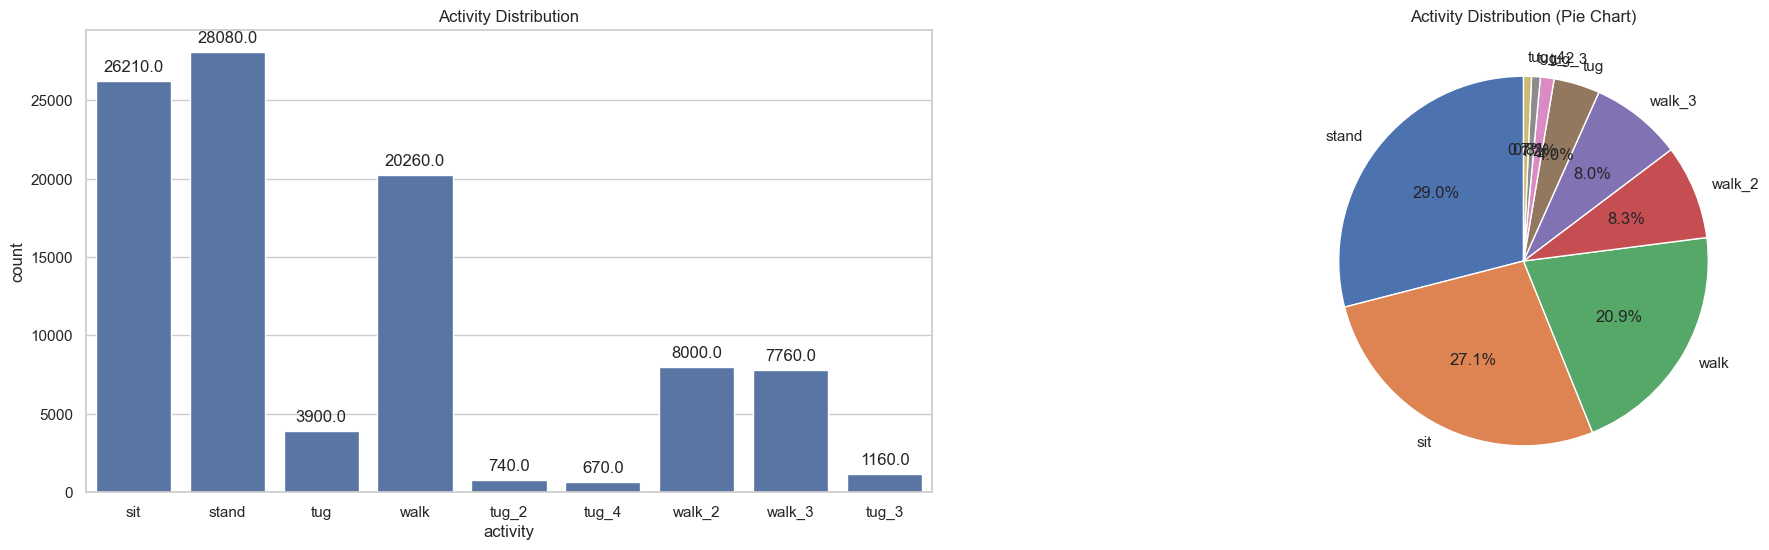

In [10]:
# Activity Distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 6))
sns.countplot(data=Dataset_A, x='activity', ax=ax1)
ax1.set_title('Activity Distribution');

for p in ax1.patches:
    ax1.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 10), textcoords='offset points')   

# pie plot of distribution of activities
activity_counts = Dataset_A['activity'].value_counts()
ax2.pie(activity_counts, labels=activity_counts.index, autopct='%1.1f%%', startangle=90)
ax2.set_title('Activity Distribution (Pie Chart)');

From the plots, we see that the dataset is imbalanced, with jogging and walking accounnting for about 70% of the samples, and sitting and standing falling far behind. 
This means that there may be a tendency for our final model to be very good at predicting the jogging or walking classes, because it has more samples to learn from. 

In [11]:
print_horizontal_line()
print(f'{len(Dataset_A)} total samples')
print_horizontal_line()
Dataset_A.describe()

-- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- 
96780 total samples
-- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -

,knee_ax,knee_ay,knee_az,knee_gx,knee_gy,knee_gz,lumbar_ax,lumbar_ay,lumbar_az,lumbar_gx,lumbar_gy,lumbar_gz,thigh_ax,thigh_ay,thigh_az,thigh_gx,thigh_gy,thigh_gz
count,96780.000000,96780.000000,96780.000000,96780.000000,96780.000000,96780.000000,96780.000000,96780.000000,96780.000000,96780.000000,96780.000000,96780.000000,96780.000000,96780.000000,96780.000000,96780.000000,96780.000000,96780.000000
mean,0.070329,-0.284943,-0.087577,2.179286,-4.035637,0.005546,0.020323,0.391641,-0.128266,1.094822,-2.050570,0.061017,-0.153358,0.059412,0.249551,1.134097,-2.679608,0.635193
std,0.243803,0.903287,0.286724,46.693527,29.539402,32.605075,0.175752,0.849411,0.261377,22.207957,21.494656,11.541308,0.330800,0.825632,0.434529,25.801644,28.070653,17.168843
min,-1.574776,-2.966552,-2.084248,-206.290000,-456.890000,-311.780000,-0.732488,-1.384944,-0.999912,-882.140000,-1176.560000,-296.520000,-1.837320,-1.953952,-2.413160,-260.190000,-243.110000,-203.350000
25%,-0.088328,-0.964288,-0.266448,0.980000,-4.620000,-1.190000,-0.075152,-0.843752,-0.334280,0.280000,-2.940000,-0.140000,-0.307440,-0.940376,-0.009760,0.980000,-3.430000,-0.560000
50%,0.099552,-0.911096,-0.093208,1.470000,-4.130000,-0.770000,-0.009272,0.908412,-0.142984,1.540000,-2.100000,0.350000,-0.098576,0.188124,0.148840,1.330000,-2.520000,-0.140000
75%,0.217160,0.945744,0.103944,1.820000,-3.430000,-0.420000,0.090768,1.003328,0.091744,2.310000,-0.840000,0.910000,-0.002440,0.961360,0.686128,1.820000,-1.680000,0.210000
max,2.140856,1.943704,1.103856,306.810000,296.730000,249.900000,1.597712,1.766072,0.785680,1364.440000,214.830000,379.400000,1.174128,1.962248,1.434720,398.720000,316.120000,282.170000


In [12]:
print(Dataset_A.isna().sum())

pc_timestamp    0
knee_ax         0
knee_ay         0
knee_az         0
knee_gx         0
knee_gy         0
knee_gz         0
lumbar_ax       0
lumbar_ay       0
lumbar_az       0
lumbar_gx       0
lumbar_gy       0
lumbar_gz       0
thigh_ax        0
thigh_ay        0
thigh_az        0
thigh_gx        0
thigh_gy        0
thigh_gz        0
user_id         0
activity        0
dtype: int64


Remove Null Values (The one sample tht is incomplete)

Remove Duplicates

In [13]:
print_horizontal_line()
print(f'{len(Dataset_A)} Samples before dropping duplicates')
Dataset_A = Dataset_A.drop_duplicates()
print(f'{len(Dataset_A)} Samples after dropping duplicates')
print_horizontal_line()

-- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- 
96780 Samples before dropping duplicates
96755 Samples after dropping duplicates
-- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- 

#### Frequency Distribution of ax, ay, az, gx, gy, gz for knee, thigh and lumbar (Frequency Distributions before cleaning)
---

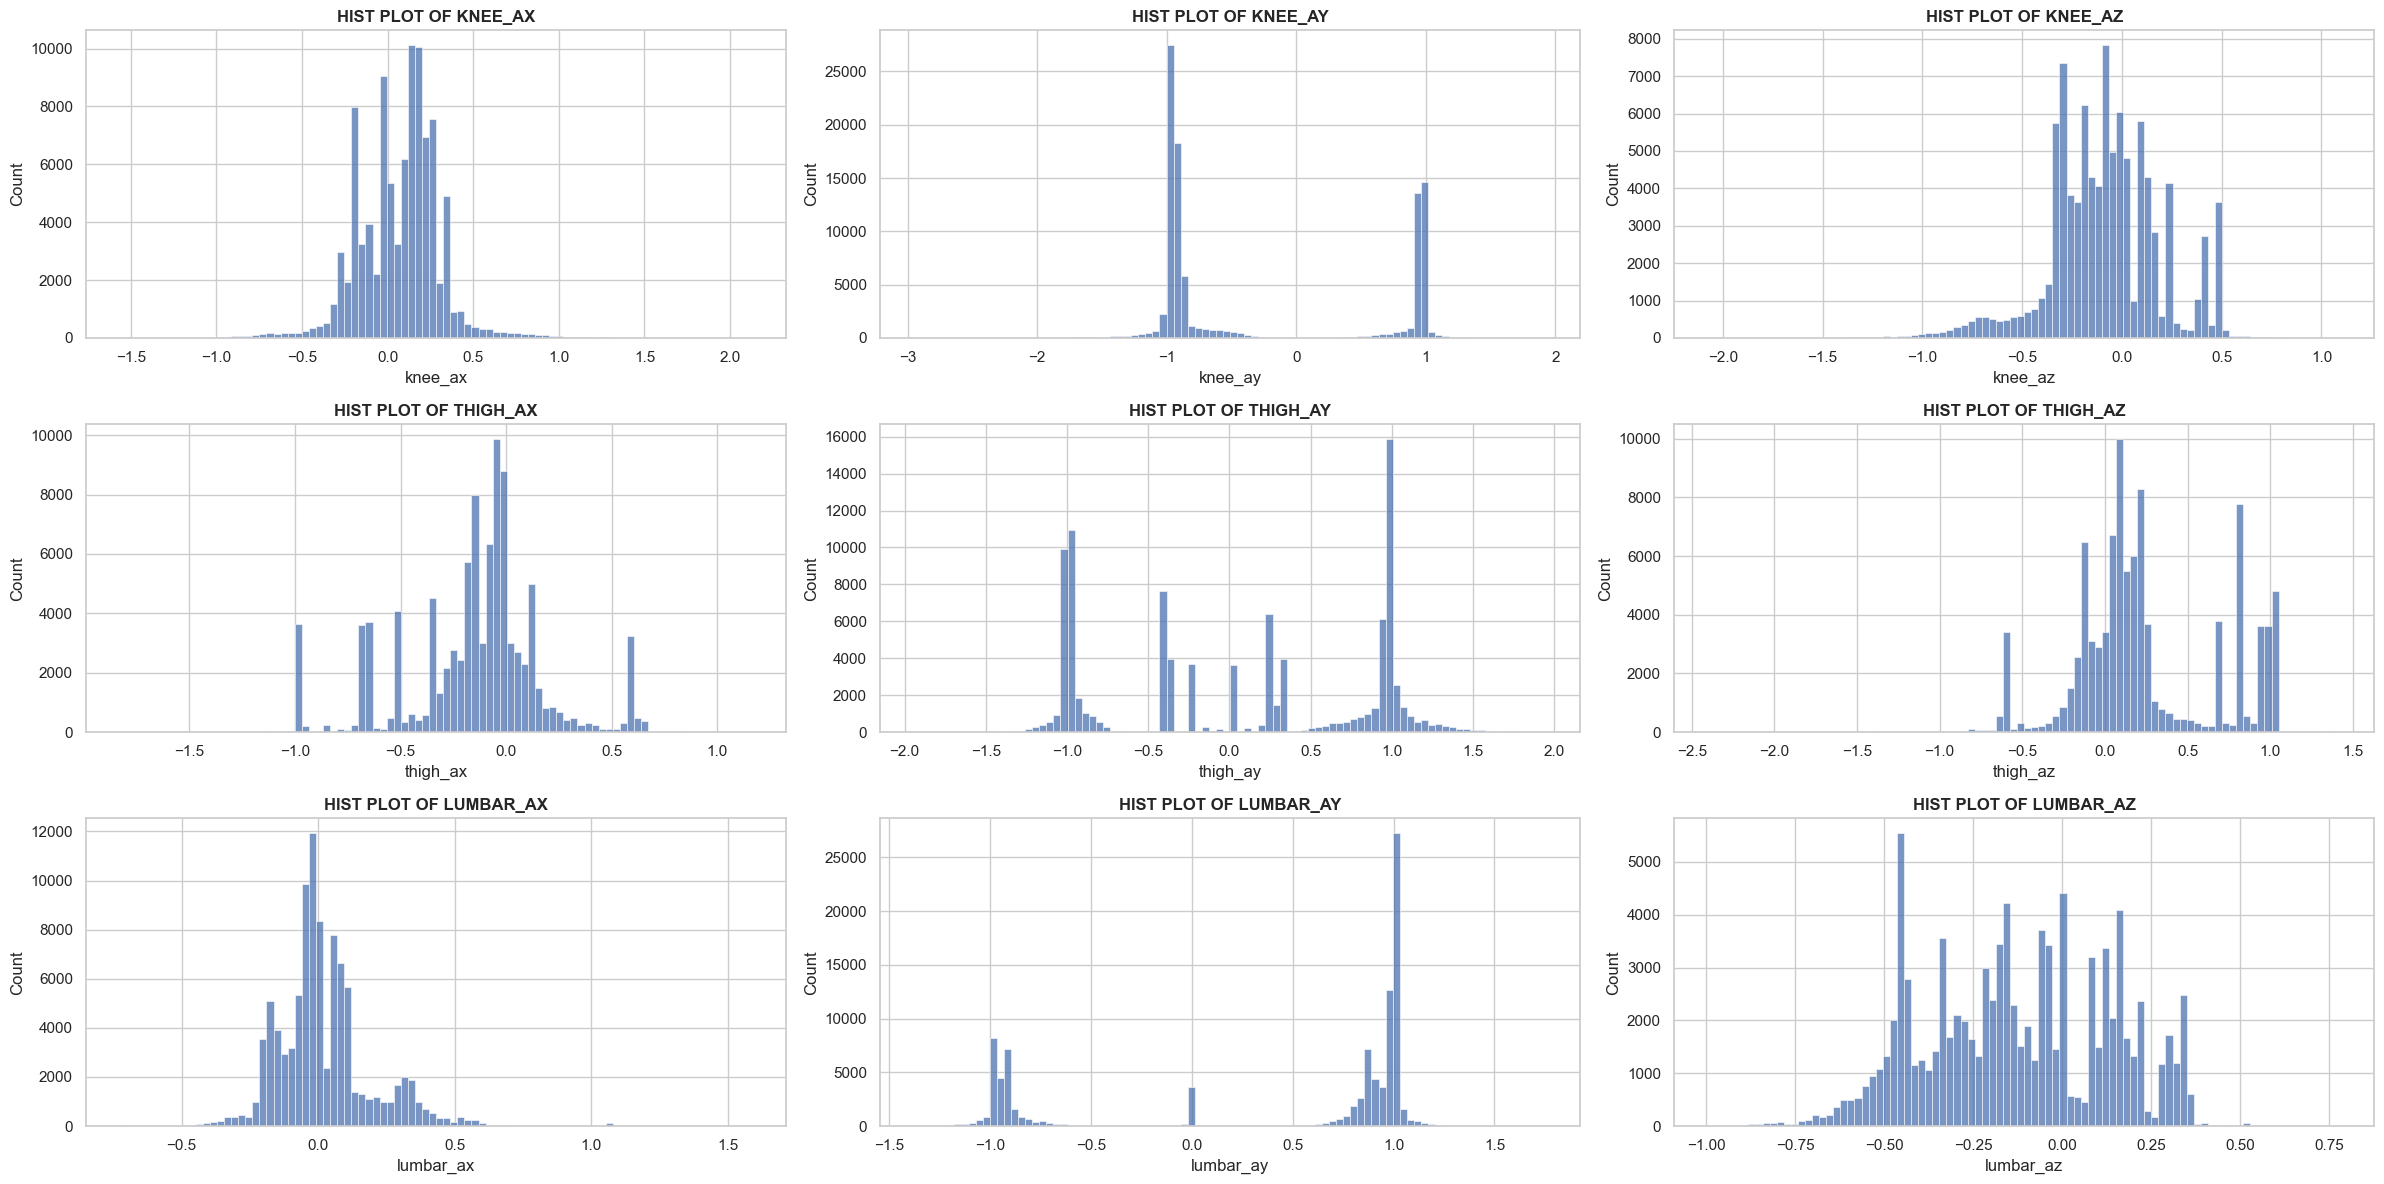

In [14]:
#### Frequency Distribution of ax, ay, az, gx, gy, gz for knee, thigh and lumbar
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(24,12))

columns_to_plot = [
    'knee_ax', 
    'knee_ay', 
    'knee_az',
    'thigh_ax', 
    'thigh_ay', 
    'thigh_az',
    'lumbar_ax', 
    'lumbar_ay', 
    'lumbar_az'
]


# 3. Zip columns and flattened axes into a single loop
for col, ax in zip(columns_to_plot, axes.flatten()):
    sns.histplot(data=Dataset_A, x=col, ax=ax, bins=90)
    ax.set_title(f"HIST PLOT OF {col.upper()}", fontweight='bold', fontsize=12)
    

plt.tight_layout()
plt.show()


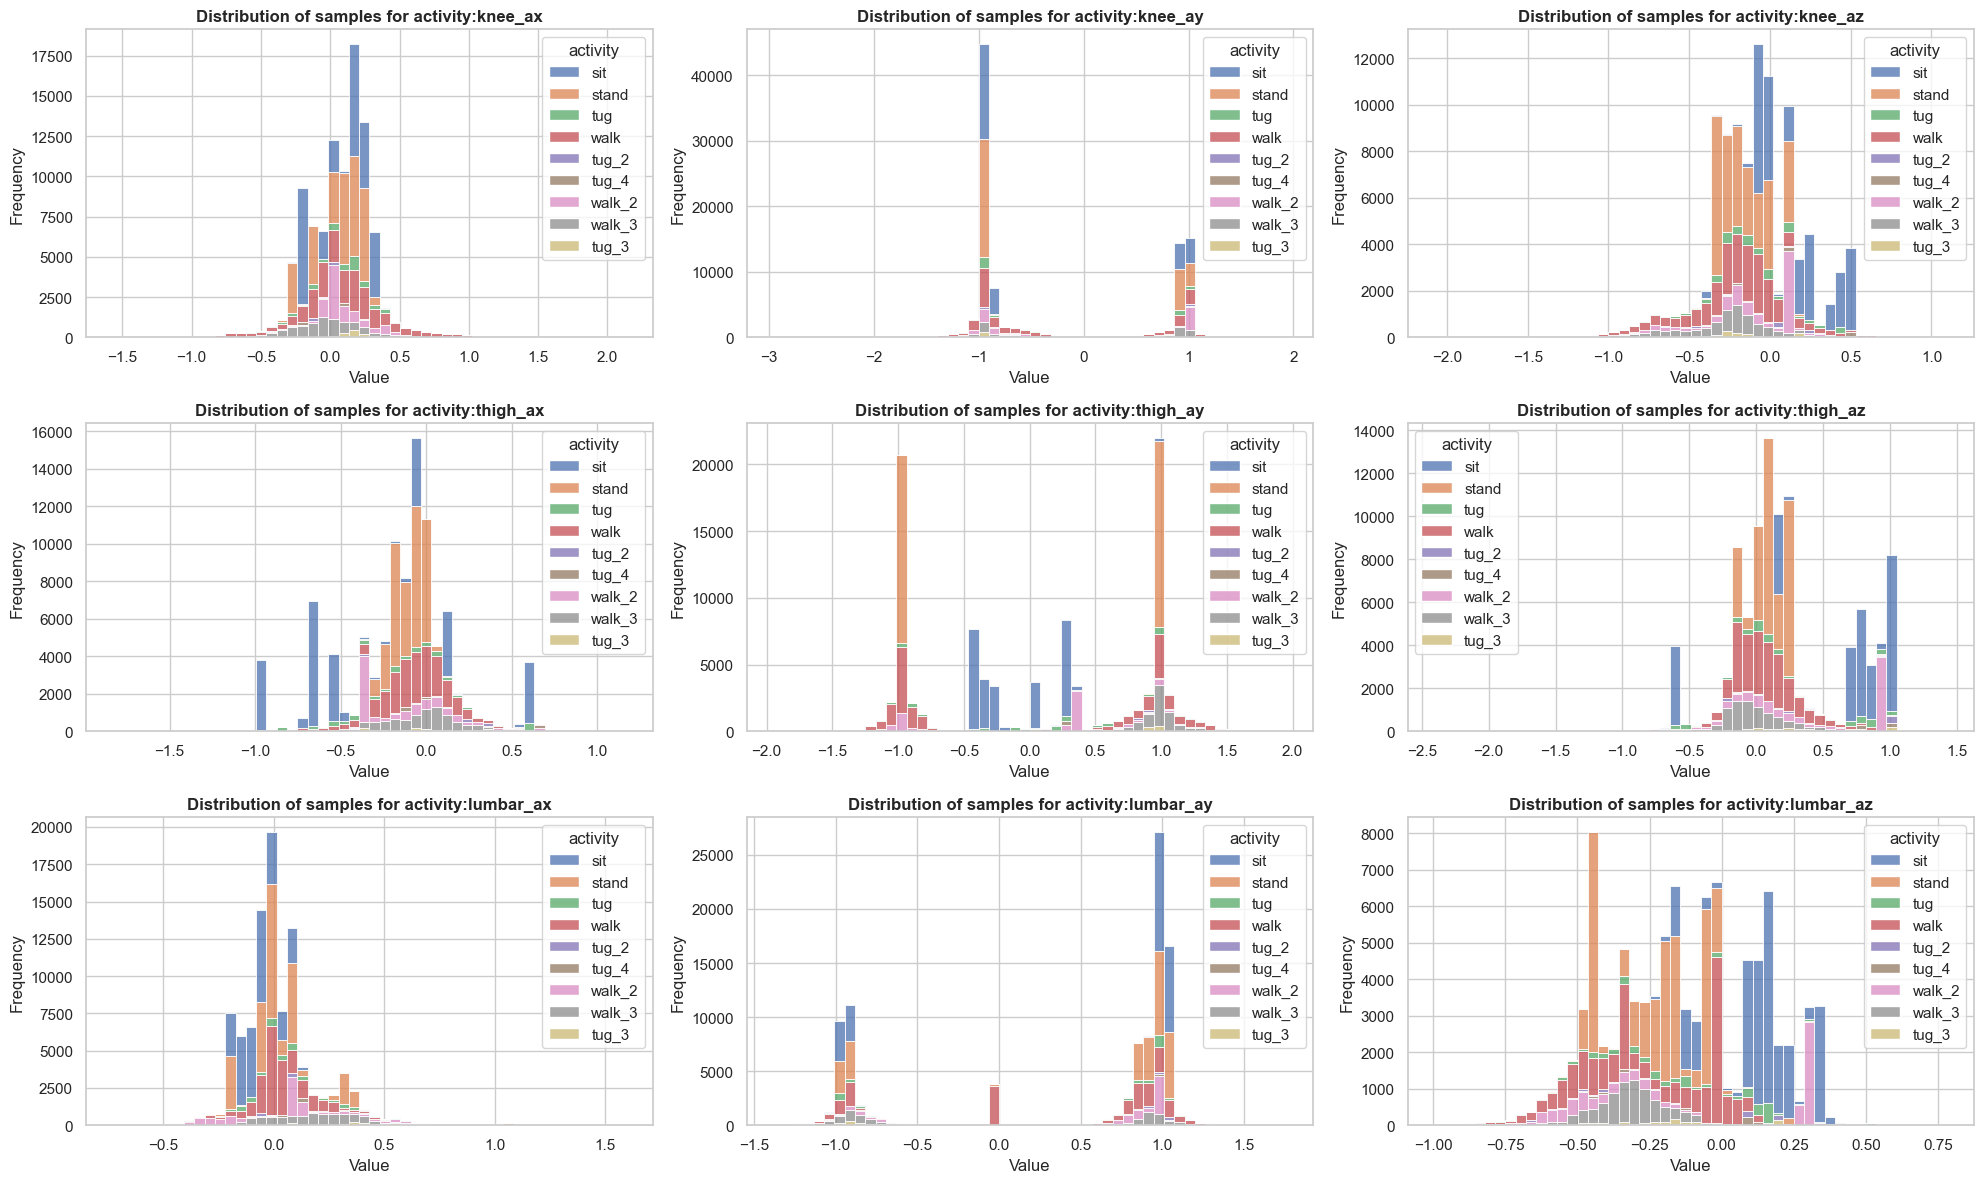

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

columns_to_plot = [
    'knee_ax', 
    'knee_ay', 
    'knee_az',
    'thigh_ax', 
    'thigh_ay', 
    'thigh_az',
    'lumbar_ax', 
    'lumbar_ay', 
    'lumbar_az'
]

# 1. Expand grid to 3x3 to fit all 9 features
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 12))

# 2. Loop through columns and target axes
for column, ax in zip(columns_to_plot, axes.flatten()):
    sns.histplot(
        data=Dataset_A, 
        x=column, 
        hue='activity', 
        bins=50, 
        multiple='stack', 
        ax=ax  # Direct output to the subplot
    )
    ax.set_title(f"Distribution of samples for activity:{column}", fontweight='bold')
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

The plots above show a heirarchy in activity types, with, standing showing the least readings, followed by sitting, stairs-decent, stairs-ascent, walking and jogging.
This supports the idea that the activity column should ordinal-encoded, with standing being the lowest value and jogging being the highest value.

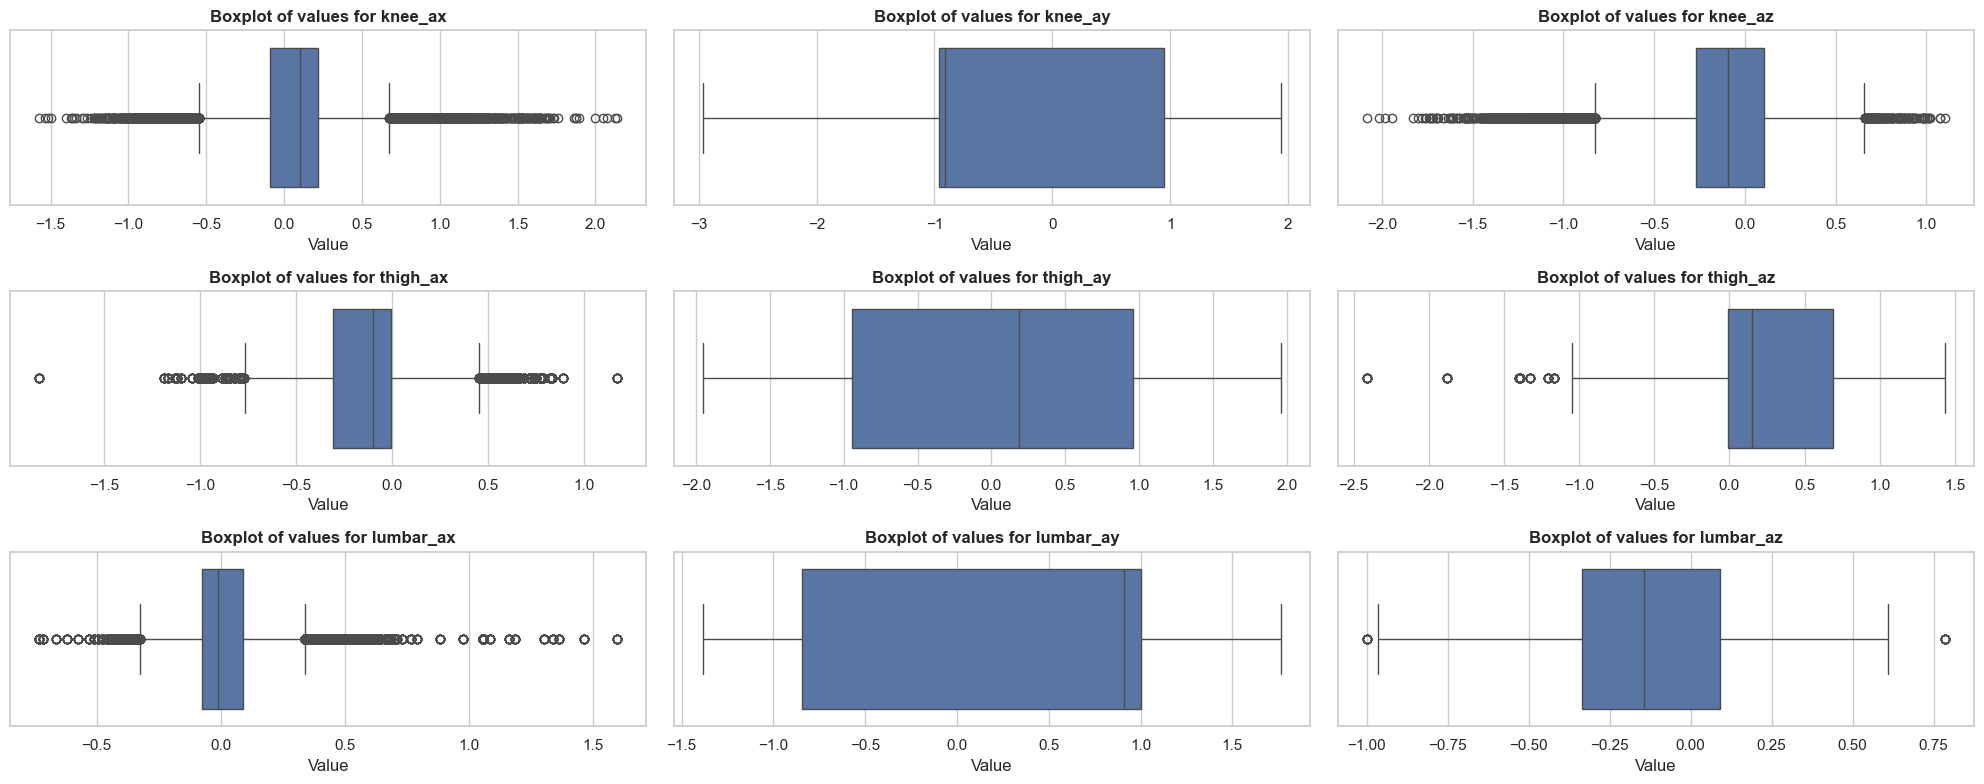

In [16]:
# plot boxplots for x, y and z values

columns_to_plot = [
    'knee_ax', 
    'knee_ay', 
    'knee_az',
    'thigh_ax', 
    'thigh_ay', 
    'thigh_az',
    'lumbar_ax', 
    'lumbar_ay', 
    'lumbar_az'
]

# 1. Expand grid to 3x3 to fit all 9 features
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 8))

# 2. Loop through columns and target axes
for column, ax in zip(columns_to_plot, axes.flatten()):
    sns.boxplot(data=Dataset_A, x=column, ax=ax);
    ax.set_title(f"Boxplot of values for {column}", fontweight='bold')
    ax.set_xlabel("Value")

plt.tight_layout()
plt.show()

The boxplots indicate that there are a lot of outliers in the accelerometer data. However, we will not remove them as they may contain important information about types and speeds of movements. Instead, we will carry on, only scaling the data using a standard scaler. This will be done in our pre-processing step

In [17]:
print_horizontal_line()
print_horizontal_line()

-- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- 
-- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- 

Our dataset is comprised of thousands of snapshots of readings from accelerometers x, y and z, together with the timestamp at which that snapshot was recorded.
While these individual snapshots are important, they do not tell the full story of what activity is being perormed. This is because realisitically, activities are a set of fluid motions (or not) that are interlinked, performed over time. 

So, to see if someone is currently running, we need to see for the past x seconds, what movements the person was performing. The x-seconds, is called a window. And or the sake of consistency, we will keep the window size constant. 

The dataset was collected at roughly 20 samples/second (20Hz) (check the frequency distributions plotted or the x, y, and z columns above) [.]. We will use 5 seconds as our window, giving us a total of 100 samples or snapshots with which to classifify activities.  

Window 1:
[
 [x1,y1,z1],
 [x2,y2,z2],
 ...
 [x100,y100,z100]
] ==> Walking


Window 2:
[
 [x1,y1,z1],
 [x2,y2,z2],
 ...
 [x100,y100,z100]
] ==> Jogging

Window 3:
[
 [x1,y1,z1],
 [x2,y2,z2],
 ...
 [x100,y100,z100]
] ==> Walking

It is also important to introduce an overlap between the windows, so that the model does not miss out on interesting information stored in at the edges of the window. We will use an overlap that is 50% of the window samples. 
While this helps paint a better picture of the activity being performed, It also translates to longer training times and more memory consumption.

In [18]:
print_horizontal_line()

-- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- 


sort dataset by user_id and timestamps

In [19]:
Dataset_A.sort_values(by=['user_id', 'pc_timestamp'], inplace=True)

#### User Distribution, Activity and Engagement
---

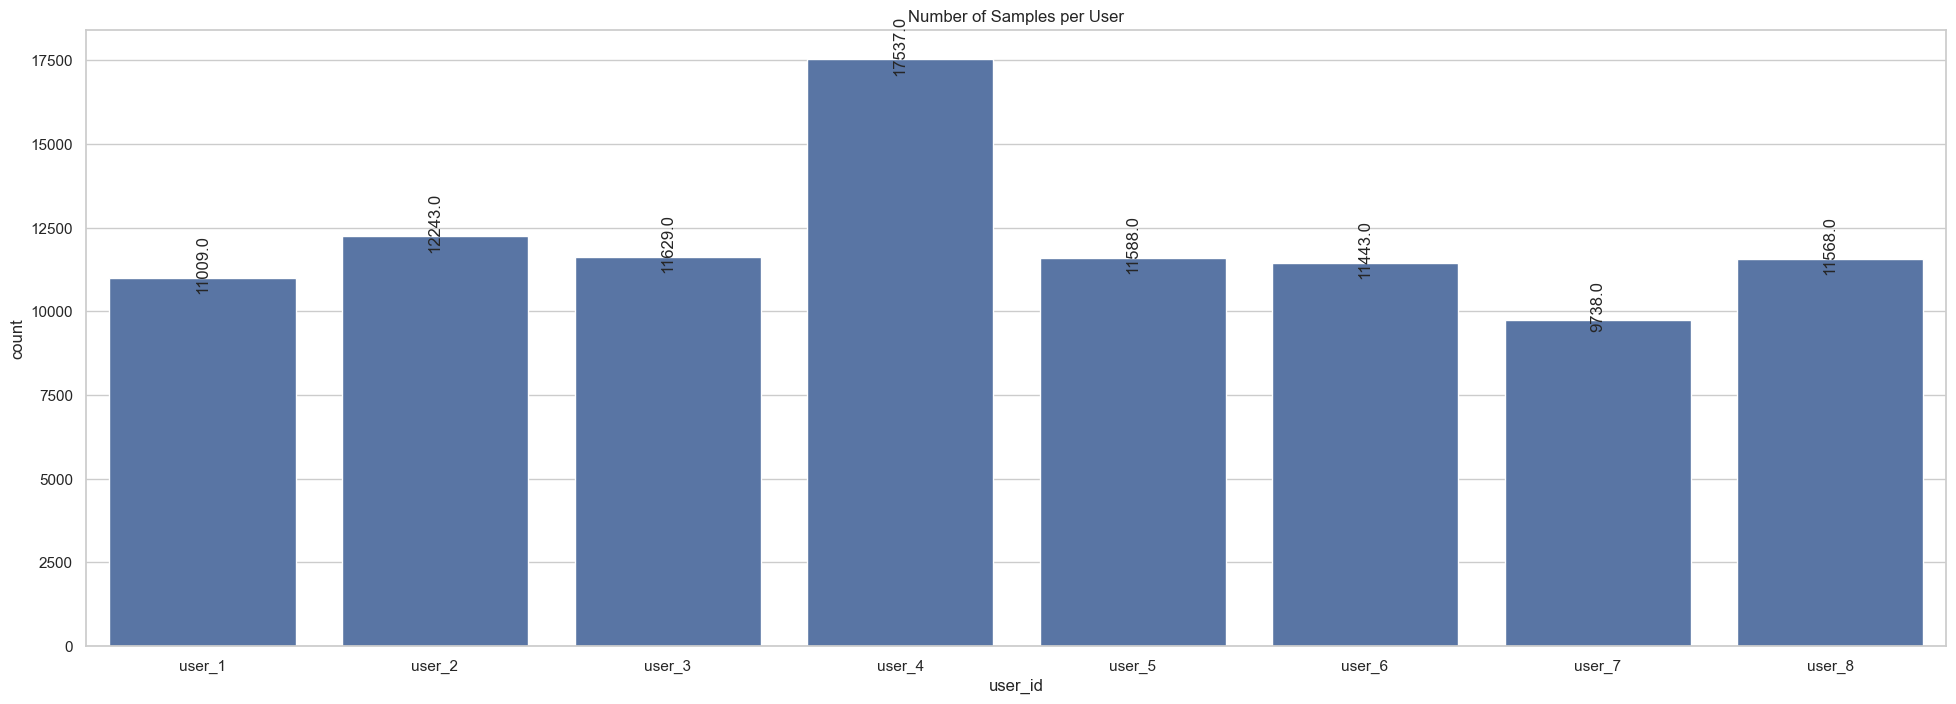

In [20]:
fig, ax1 = plt.subplots(1, 1, figsize=(24, 8))
# bar plot of distribution of number of samples per user
sns.countplot(data=Dataset_A, x='user_id', ax=ax1)
ax1.set_title('Number of Samples per User');
for p in ax1.patches:

    # set the annotation to be vertical
    ax1.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 10), textcoords='offset points', rotation=90) 

##### Did every user perform every activity?
---
User-level analysis is particularly important in human activity recognition because individuals exhibit unique movement patterns. To avoid data leakage and ensure generalizability, subject-independent evaluation methods such as leave-one-subject-out validation should be considered rather than random train-test splits.

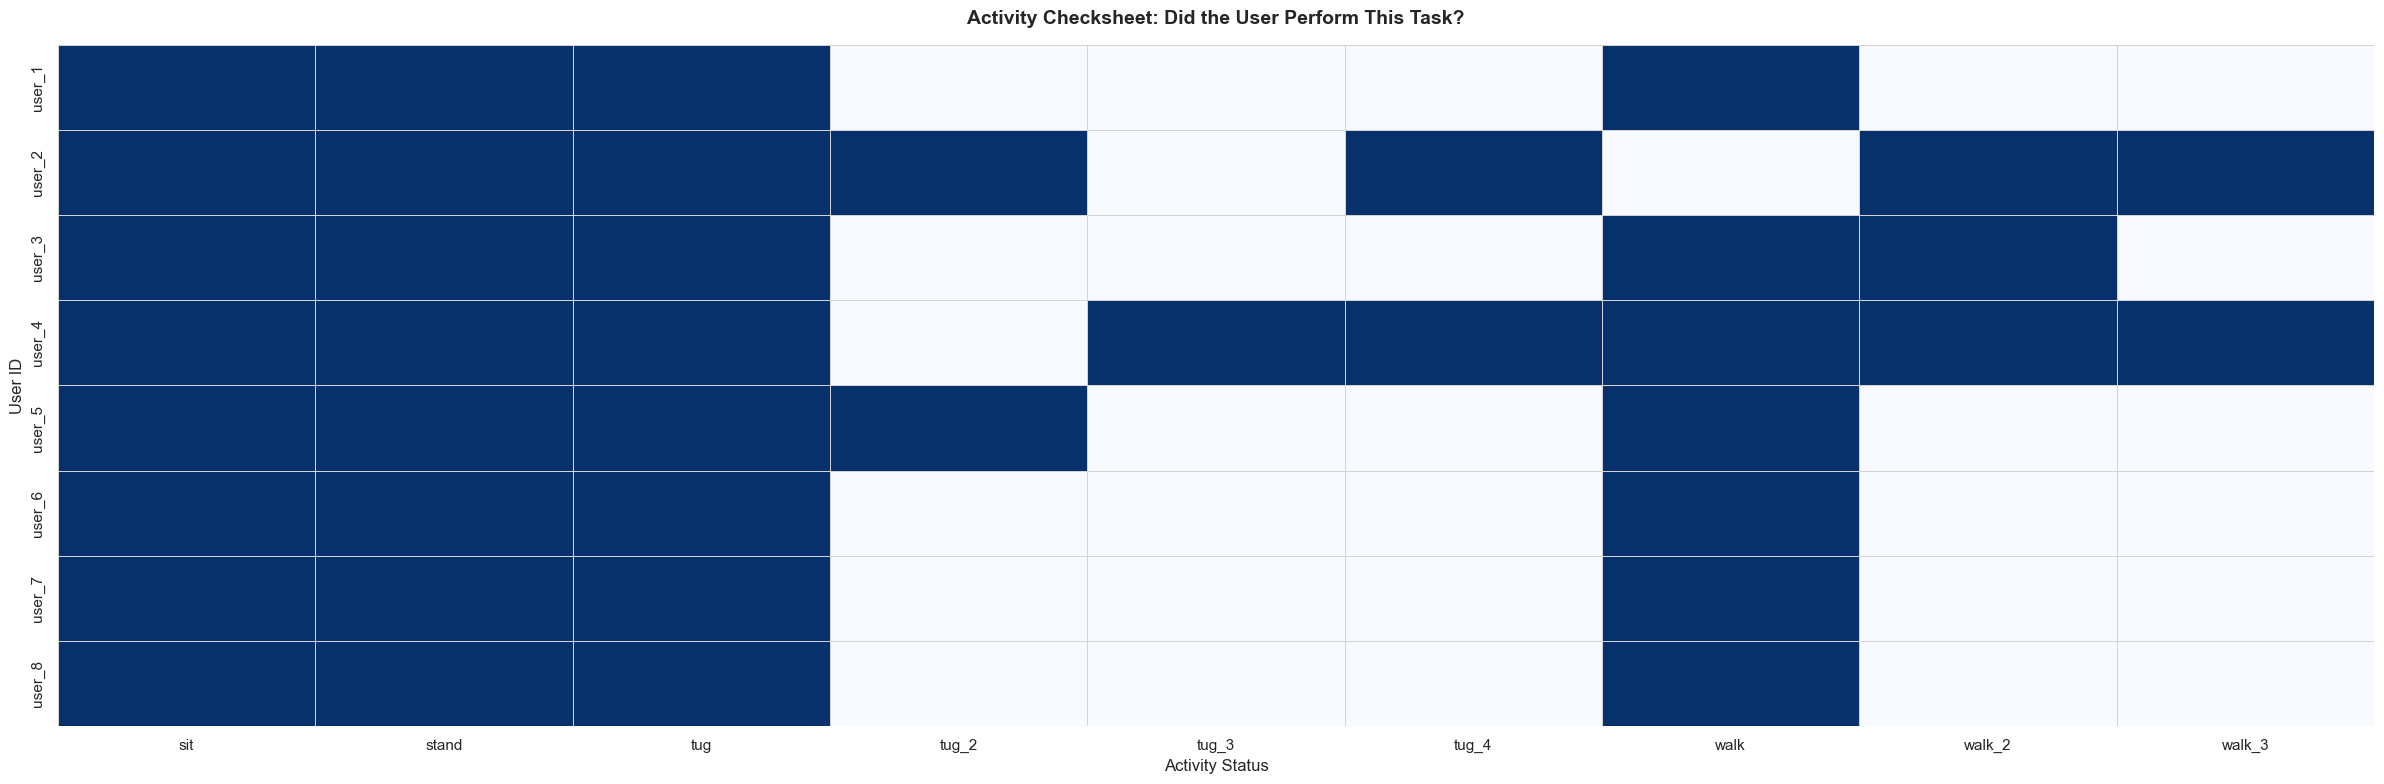

In [21]:
#check if each user performed all activities
check_list = pd.crosstab(
    Dataset_A["user_id"],
    Dataset_A["activity"]
)
# Convert sample counts into binary flags: 1 if they did it at all, 0 if completely missing
completion_matrix = (check_list > 0).astype(int)

plt.figure(figsize=(24, 8))
sns.heatmap(
    completion_matrix, 
    cmap="Blues", 
    cbar=False, 
    linewidths=0.5, 
    linecolor='lightgray'
)

plt.title("Activity Checksheet: Did the User Perform This Task?", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("User ID", fontsize=12)
plt.xlabel("Activity Status", fontsize=12)
plt.tight_layout()
plt.show()

---
The thing to note here is that, not all users performed all the activities. User 9, for example, only walked. User 2, only performed jogging and walking. 
Ultimately, Sitting and Standing are poorly represented. Overall, there is a risk that the model may learn person-specific patterns and not generalize properly.

As part of our model training, we will need to split the data into training and test sets. However, we won't be randomly splitting our data into these sets. 
We will split based on `user_id's`, using some samples `A-V` to train, `V-X` to test, and `Y-Z` to validate the performance of the model.

In [22]:
print_horizontal_line()
print_horizontal_line()

-- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- 
-- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- 

##### Comparison of accelerator values for different activities performed by one user (who completed all activities)
---

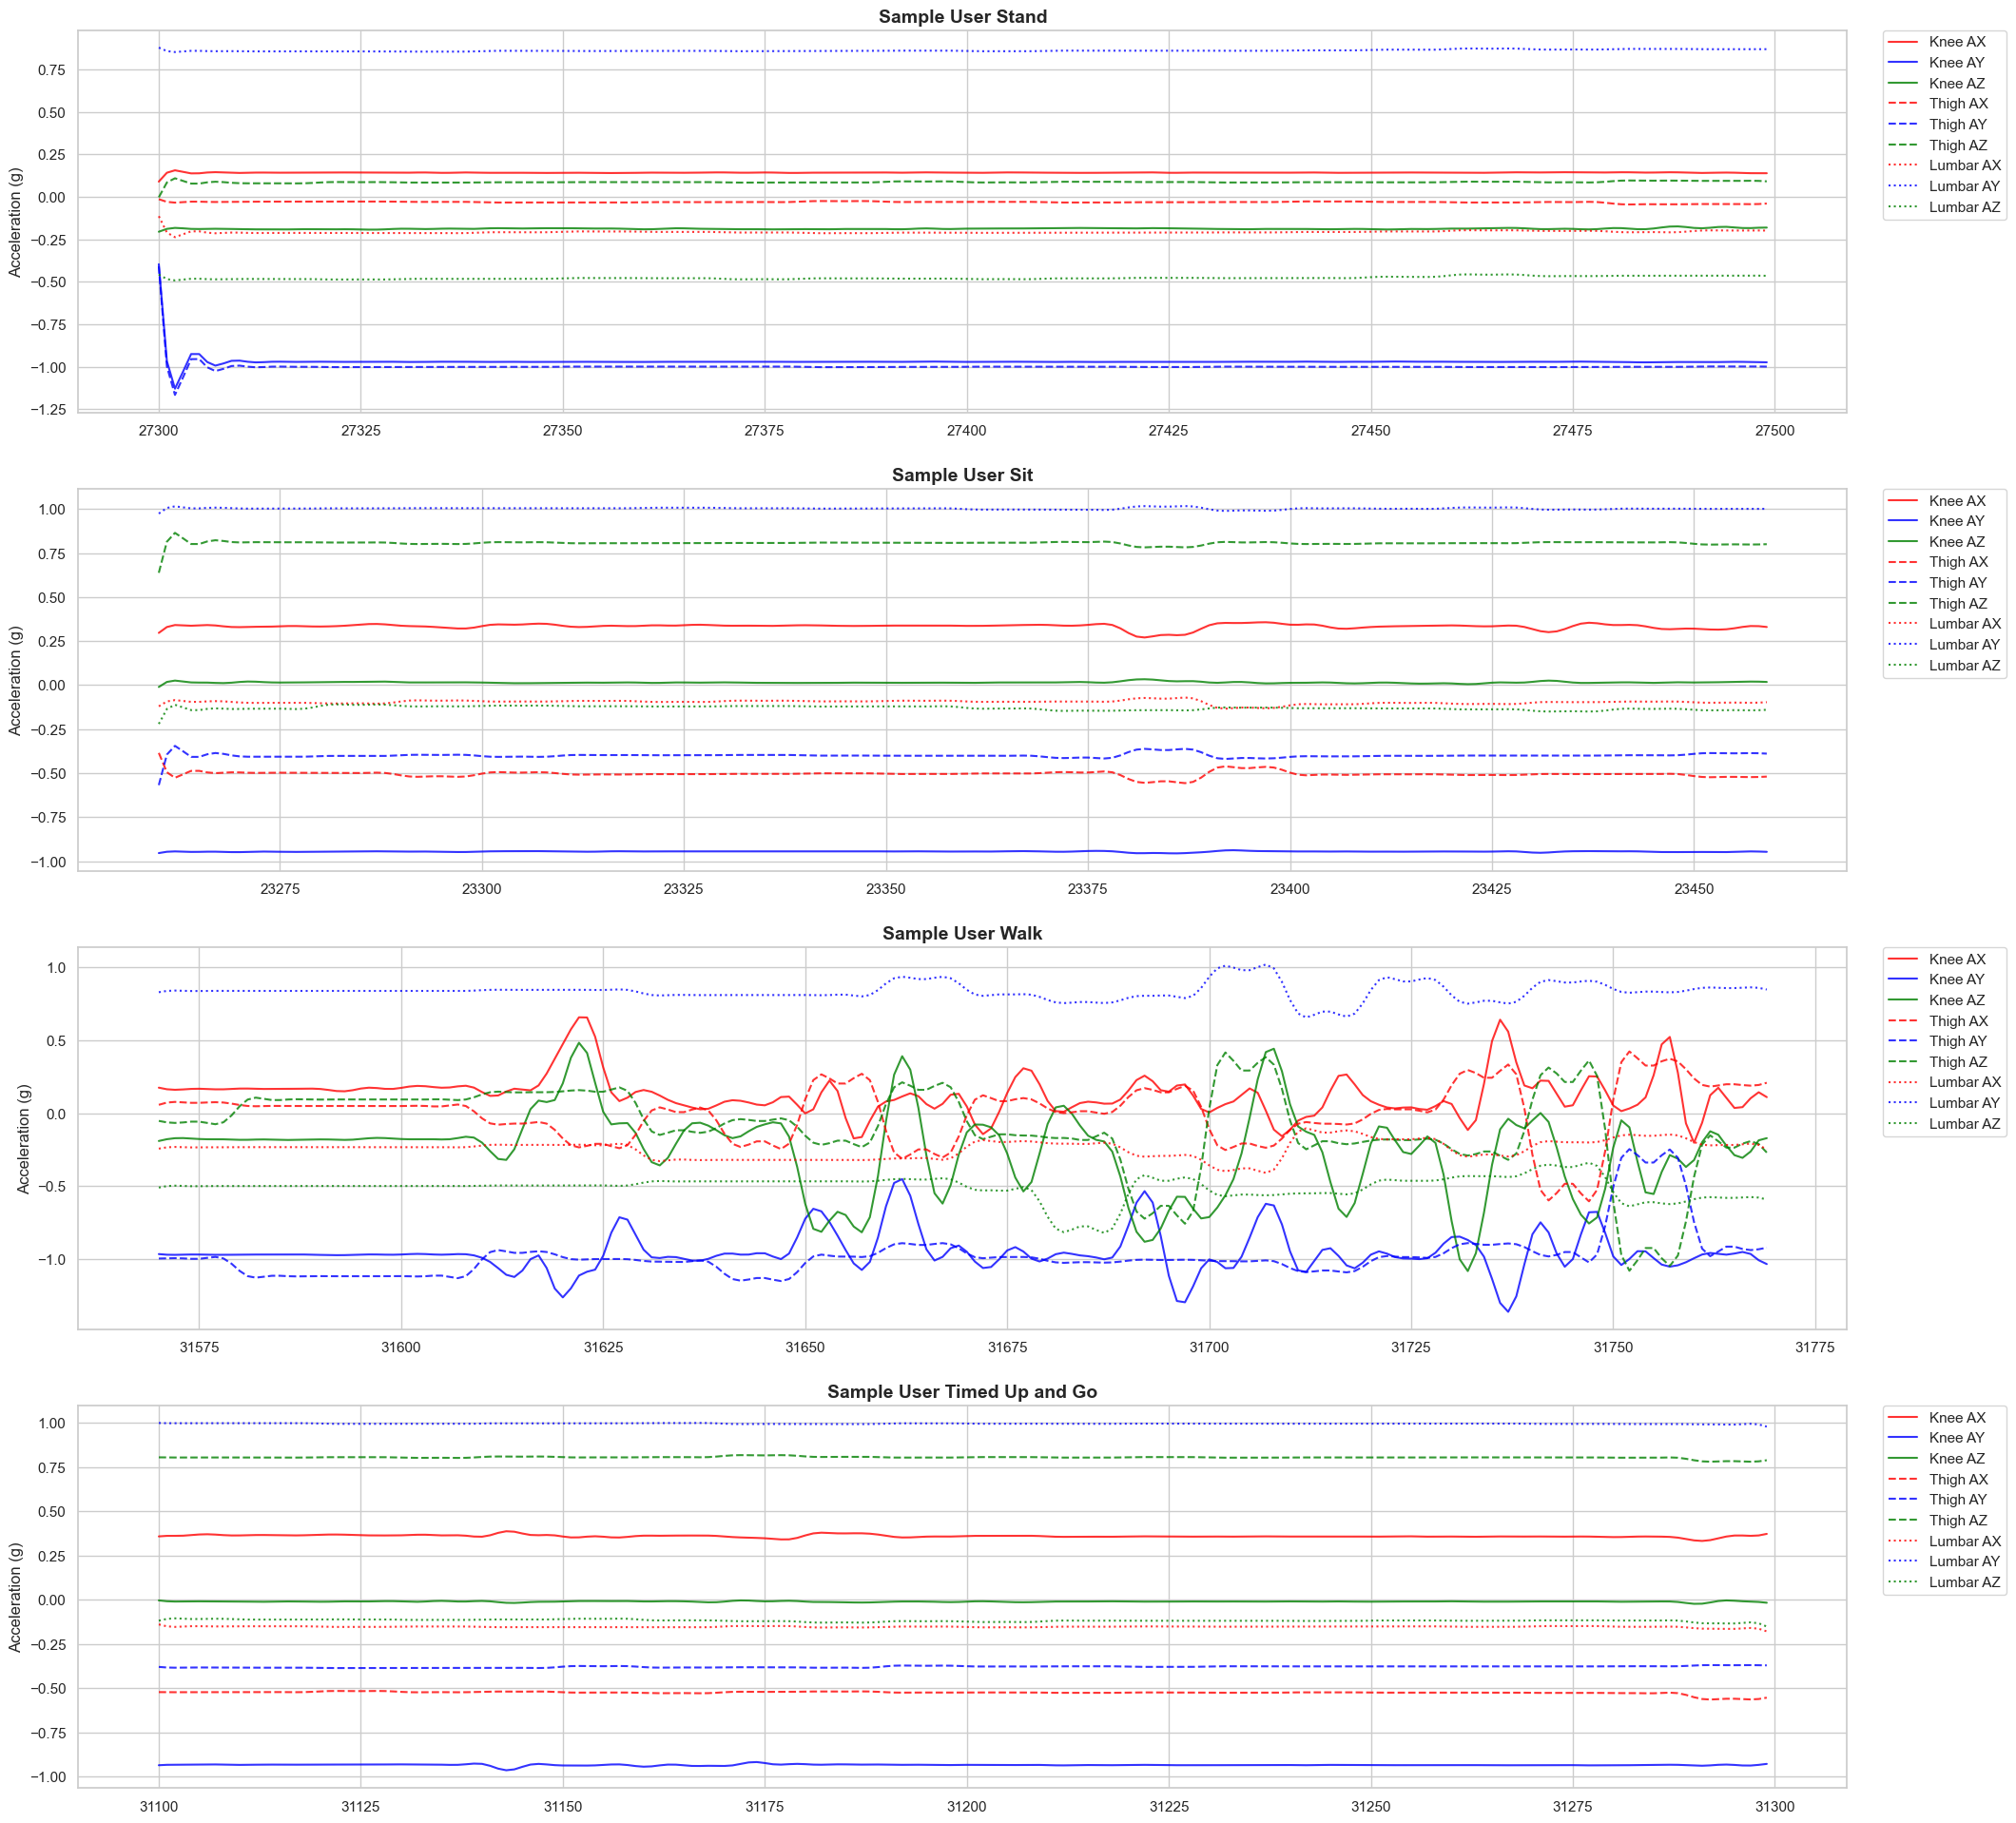

In [26]:
def get_user_activity_data(df, user_id, activity, num_samples=200):
    """Filters data for a specific user and activity, and returns a small sample."""
    sample = df[(df['user_id'] == f"user_{user_id}") & (df['activity'] == activity)].head(num_samples)
    return sample    

def plot_user_activity_sample(sample_df, title, ax, columns=None):
    '''Plots all 9 IMU sensor channels for a specific user and activity.'''
    if columns is None:
        columns = [
            'knee_ax', 'knee_ay', 'knee_az',
            'thigh_ax', 'thigh_ay', 'thigh_az',
            'lumbar_ax', 'lumbar_ay', 'lumbar_az'
        ]

    # Map axis to color and body node to line style
    color_map = {'ax': 'red', 'ay': 'blue', 'az': 'green'}
    style_map = {'knee': '-', 'thigh': '--', 'lumbar': ':'}

    for col in columns:
        if col in sample_df.columns:
            node, axis = col.split('_')  # Extracts 'knee' and 'ax'
            
            ax.plot(
                sample_df.index,
                sample_df[col],
                label=f"{node.capitalize()} {axis.upper()}",
                color=color_map.get(axis, 'black'),
                linestyle=style_map.get(node, '-'),
                alpha=0.8
            )

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel('Acceleration (g)', fontsize=12)
    
    # Place legend outside the plot so it doesn't cover the data
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)

def get_sample_user_data(user_id):

    sample_user_walk = get_user_activity_data(Dataset_A, user_id=user_id, activity='walk', num_samples=200) 
    sample_user_stand = get_user_activity_data(Dataset_A, user_id=user_id, activity='stand', num_samples=200)
    sample_user_sit = get_user_activity_data(Dataset_A, user_id=user_id, activity='sit', num_samples=200)
    sample_user_tug = get_user_activity_data(Dataset_A, user_id=user_id, activity='tug', num_samples=200)
    
    return (sample_user_walk, sample_user_stand, sample_user_sit, sample_user_tug)


sample_user_walk, sample_user_stand, sample_user_sit, sample_user_tug = get_sample_user_data(SAMPLE_USER)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=4, ncols=1, figsize=(24, 24))

plot_user_activity_sample(sample_user_stand, "Sample User Stand", ax1)
plot_user_activity_sample(sample_user_sit, "Sample User Sit", ax2)
plot_user_activity_sample(sample_user_walk, "Sample User Walk", ax3);
plot_user_activity_sample(sample_user_tug, "Sample User Timed Up and Go", ax4)


As shown in the plot above, the patterns recorded by the accelerometers differ with respect to activity. While walking, stairs-ascent and decent and jogging produce regular heavy spikes in the readings of the accelerometers, sitting and standing generally experience less violent spikes, and they happen far less frequently. 

somethings to note here are the frequency of the spikes and their amplitudes.
Also, there is a significant difference between the Y values for sitting and standing, with sitting recording lower values in general than standing. 

[todo: ask Prof how to explain this. In my opinion, it's because the gravitational pull has a stronger impact on the phone because it isn't resting on anything (as against when sitting...  to validate this, maybe compare the lowers points recorded for Y when jogging, walking etc.)]


---
#### Data Preprocessing
---

Human activity usually occurs at around 3.0Hz to 4.0Hz. Because of this, it is safe to assume that accelerometers that fall outside of this may be noise generated by the sensors and the effects of movements. 

To make sure that we are tracking only human activity, we need to filter out the noise. Below, we use a low pass filter, keeping our Nyquist frequency at 10Hz (half of our accelerometer sampling rates)

In [24]:
from scipy.signal import butter, filtfilt
print_horizontal_line()

print(f'{len(Dataset_A)} total samples before filtering')
       
print_horizontal_line()
# Define the filter properties
# The WISDM dataset is typically sampled at 20Hz. We set a cut-off at 4.0Hz 
# to capture human movement while filtering out high-frequency noise/vibrations.
def butter_lowpass_filter(data, cutoff=4.0, fs=20.0, order=4):
    nyq = 0.5 * fs  # Nyquist Frequency (absolute limit of the sensors, where readings can be captured without distortion)
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    # filtfilt applies the filter forward and backward to ensure zero-phase shift
    return filtfilt(b, a, data)

# Apply to your existing dataframe columns
# Make sure to run this *after* your dropna() / drop_duplicates() steps
for axis in columns_to_plot:
    Dataset_A[axis] = butter_lowpass_filter(Dataset_A[axis].values) # assign the filters

print(f'{len(Dataset_A)} total samples after filtering')
print_horizontal_line()

-- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- 
96755 total samples before filtering
-- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- --

Plot User 33's data after denoising

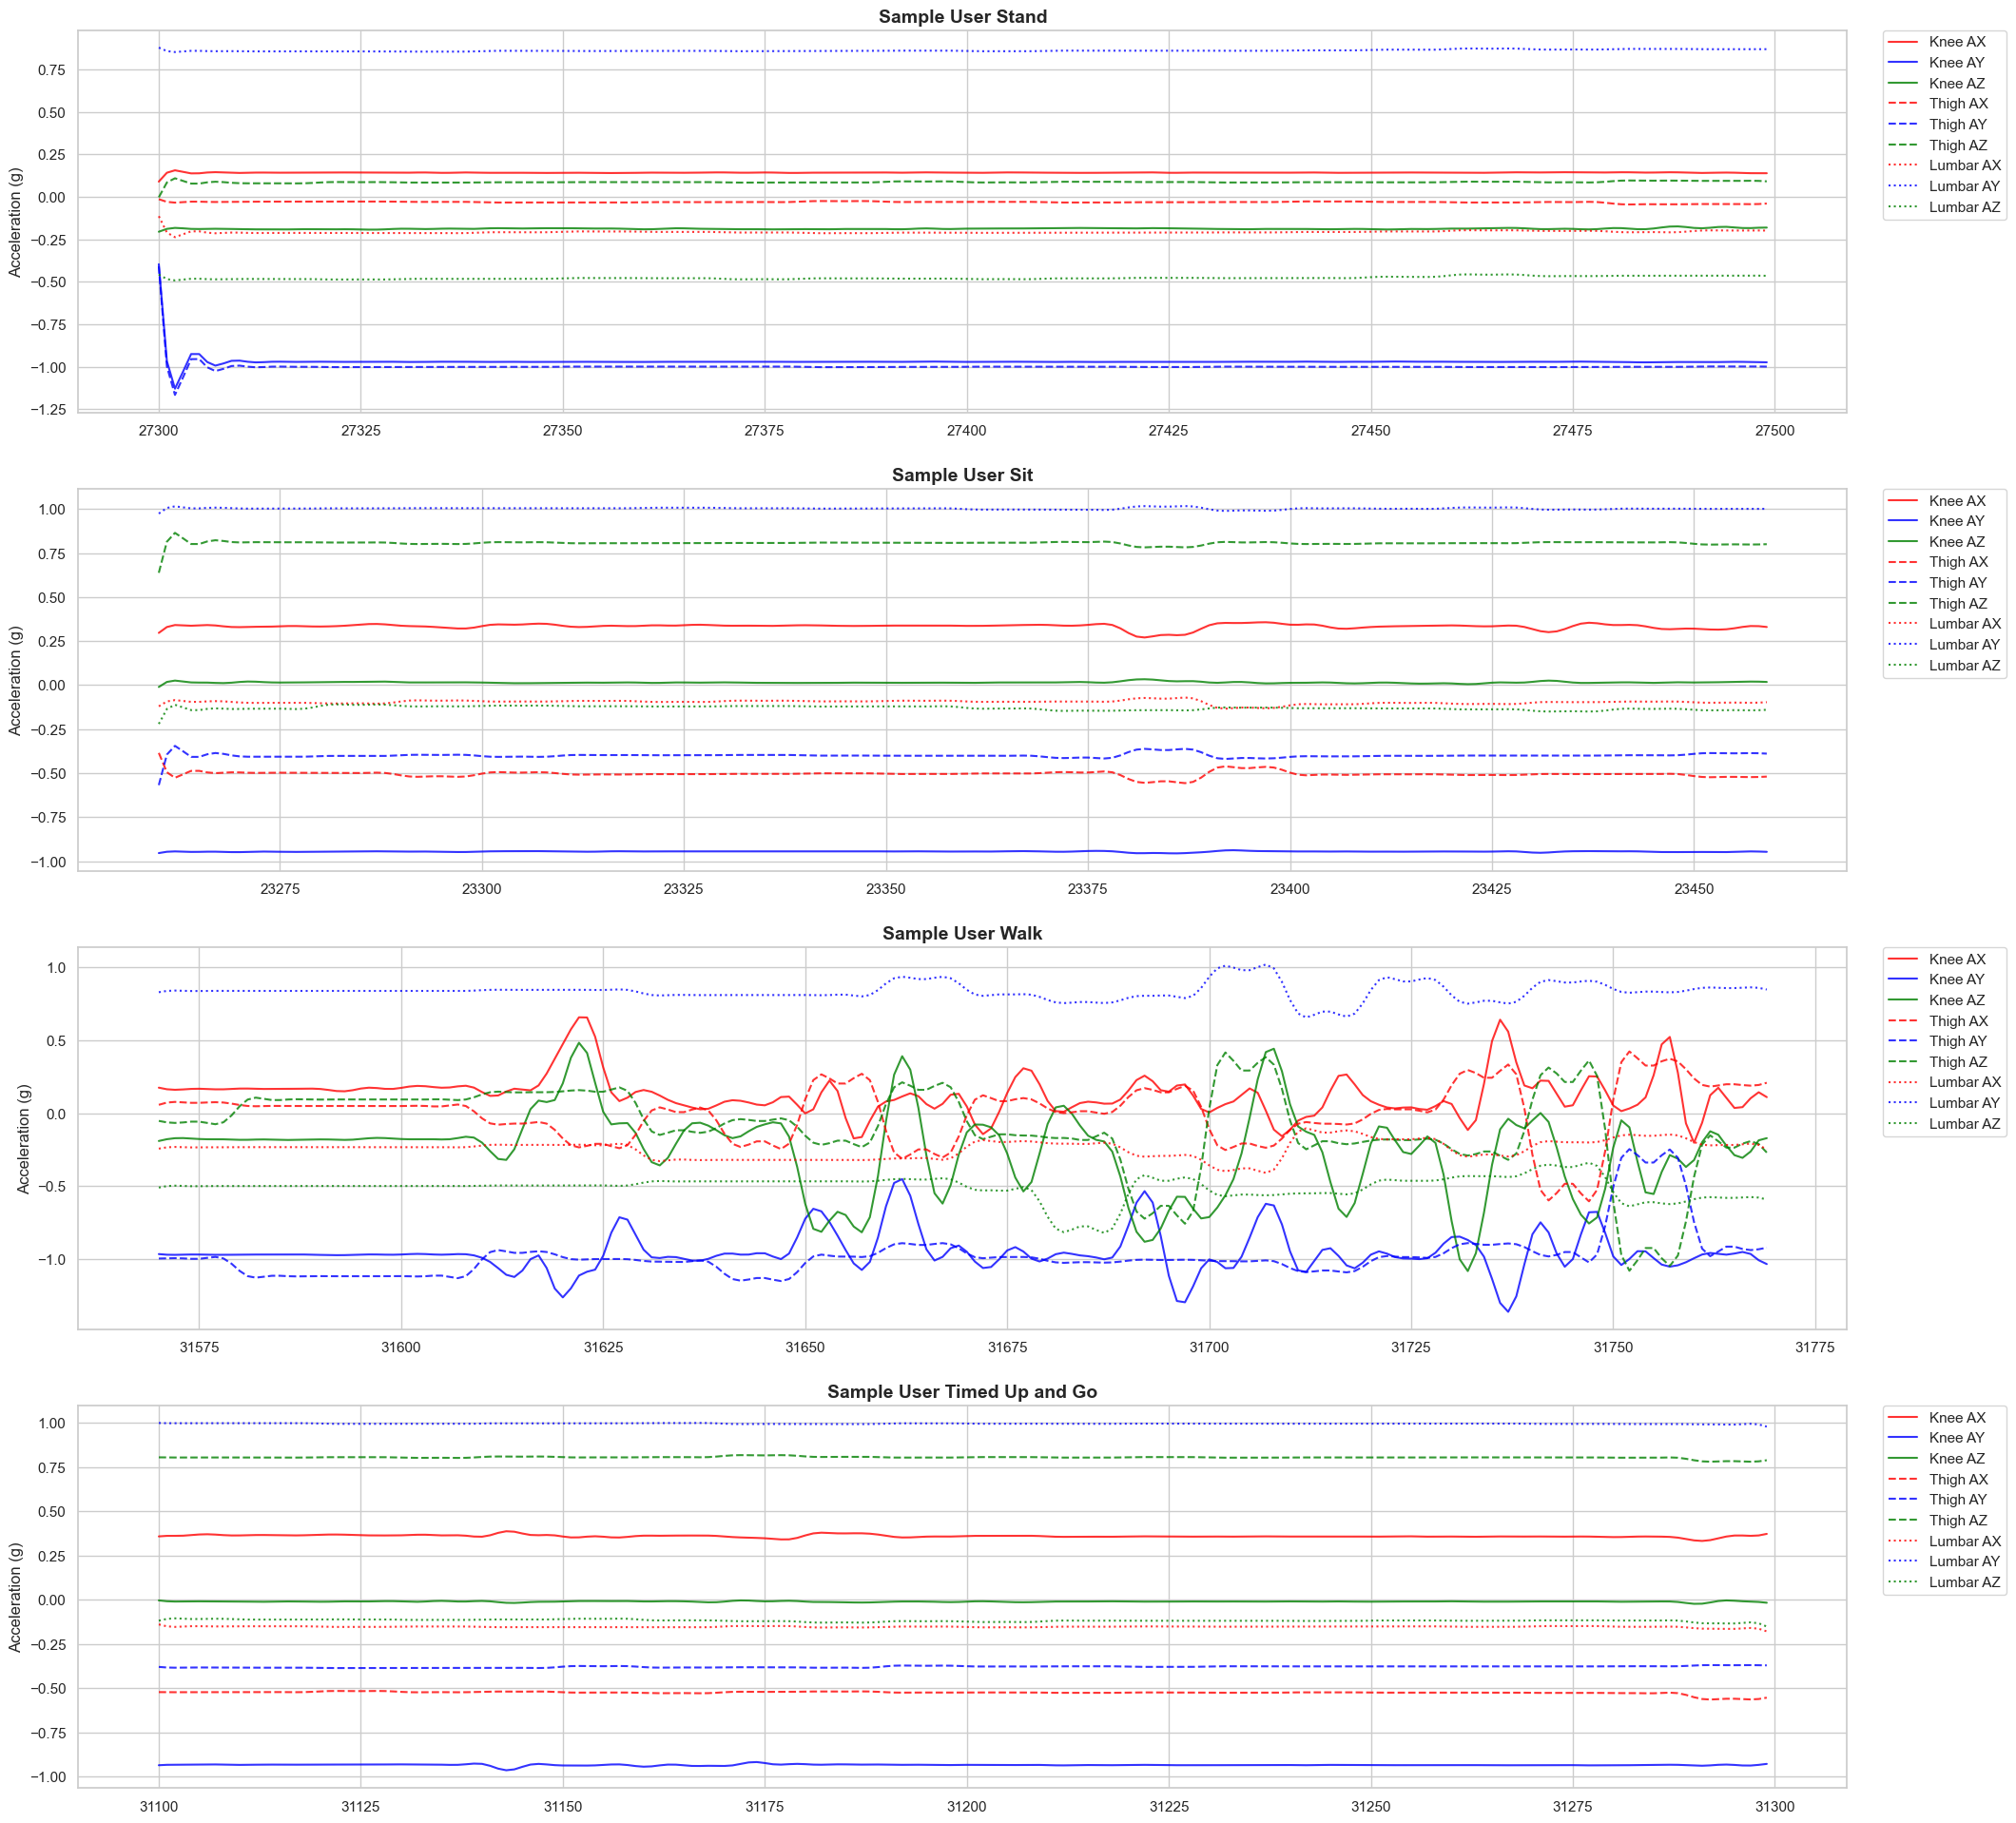

In [27]:
sample_user_walk, sample_user_stand, sample_user_sit, sample_user_tug = get_sample_user_data(SAMPLE_USER)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=4, ncols=1, figsize=(24, 24))

plot_user_activity_sample(sample_user_stand, "Sample User Stand", ax1)
plot_user_activity_sample(sample_user_sit, "Sample User Sit", ax2)
plot_user_activity_sample(sample_user_walk, "Sample User Walk", ax3);
plot_user_activity_sample(sample_user_tug, "Sample User Timed Up and Go", ax4)


##### Feature Engineering
___
While the x,y and z components are very important in activity classification, there are other pieces of information that are often needed. These bits of infomration need to be derived from the accelerometer values. 

1. Signal Magnitude Vector: The total acceleration experienced by phone, regardless of direction.
   [Magnitude = √(x² + y² + z²)]
2. Roll: How much the phone is rotated sideways [Roll = atan2(y, z) × (180/π)]
3. Pitch: Pitch measures forward and backward tilt. Pitch = atan2(
    -x,
    √(y² + z²)
)
4. Jerk: How quickly acceleration changes. Jerk_x = (x_t - x_(t-1)) / Δt
5. Magnitude of Jerk: Overall rate of change of acceleration
6. Mean acceleration: The average acceleration over a time window
   

##### Accelerometer Engineered features
---

In [ ]:
def add_accelerometer_features(
    df,
    nodes=("knee", "thigh", "lumbar"),
    sampling_rate_hz=SAMPLING_RATE_HZ,
    rolling_window_seconds=5.0
):
    """
    Creates accelerometer-derived features without modifying the original DataFrame.

    Features are calculated independently within contiguous activity sessions
    for each participant.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataset.

    nodes : tuple
        IMU node prefixes.

    sampling_rate_hz : int
        Sensor sampling frequency in Hz.

    rolling_window_seconds : float
        Duration of rolling window in seconds.

    Returns
    -------
    pd.DataFrame
        Copy of the dataset with accelerometer-derived features.
    """

    data = df.copy()

    dt = 1.0 / sampling_rate_hz

    rolling_window_samples = int(
        rolling_window_seconds * sampling_rate_hz
    )

    # -----------------------------------------------------------------------
    # SORT DATA CHRONOLOGICALLY
    # -----------------------------------------------------------------------

    time_candidates = [
        "pc_timestamp",
    ]

    time_col = next(
        (col for col in time_candidates if col in data.columns),
        None
    )

    if time_col is not None:
        data = data.sort_values(
            ["user_id", time_col]
        ).reset_index(drop=True)

    # -----------------------------------------------------------------------
    # CREATE CONTIGUOUS SESSION IDS
    # -----------------------------------------------------------------------

    data["activity_clean"] = (
        data["activity"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    data["session_id"] = (
        (data["user_id"] != data["user_id"].shift())
        |
        (data["activity_clean"] != data["activity_clean"].shift())
    ).cumsum()

    # -----------------------------------------------------------------------
    # FEATURE ENGINEERING
    # -----------------------------------------------------------------------

    for node in nodes:

        ax = f"{node}_ax"
        ay = f"{node}_ay"
        az = f"{node}_az"

        required_cols = [ax, ay, az]

        if not all(col in data.columns for col in required_cols):

            print(
                f"Skipping accelerometer features for '{node}'. "
                f"Missing one or more columns: {required_cols}"
            )

            continue

        # -------------------------------------------------------------------
        # 1. ACCELERATION MAGNITUDE
        # -------------------------------------------------------------------

        data[f"{node}_accel_mag"] = np.sqrt(
            data[ax] ** 2
            +
            data[ay] ** 2
            +
            data[az] ** 2
        )

        # -------------------------------------------------------------------
        # 2. ROLL
        # -------------------------------------------------------------------

        data[f"{node}_roll"] = np.degrees(
            np.arctan2(
                data[ay],
                data[az]
            )
        )

        # -------------------------------------------------------------------
        # 3. PITCH
        # -------------------------------------------------------------------

        data[f"{node}_pitch"] = np.degrees(
            np.arctan2(
                -data[ax],
                np.sqrt(
                    data[ay] ** 2
                    +
                    data[az] ** 2
                )
            )
        )

        # -------------------------------------------------------------------
        # 4. JERK
        #
        # IMPORTANT:
        # Calculated inside each contiguous session so the derivative does not
        # cross from one activity/user into another.
        # -------------------------------------------------------------------

        data[f"{node}_jerk_x"] = (
            data.groupby("session_id")[ax]
            .diff()
            / dt
        )

        data[f"{node}_jerk_y"] = (
            data.groupby("session_id")[ay]
            .diff()
            / dt
        )

        data[f"{node}_jerk_z"] = (
            data.groupby("session_id")[az]
            .diff()
            / dt
        )

        data[f"{node}_jerk_mag"] = np.sqrt(
            data[f"{node}_jerk_x"] ** 2
            +
            data[f"{node}_jerk_y"] ** 2
            +
            data[f"{node}_jerk_z"] ** 2
        )

        # -------------------------------------------------------------------
        # 5. ENERGY
        # -------------------------------------------------------------------

        data[f"{node}_energy_x"] = data[ax] ** 2
        data[f"{node}_energy_y"] = data[ay] ** 2
        data[f"{node}_energy_z"] = data[az] ** 2

        data[f"{node}_accel_energy"] = (
            data[ax] ** 2
            +
            data[ay] ** 2
            +
            data[az] ** 2
        )

        # -------------------------------------------------------------------
        # 6. ROLLING MEAN ACCELERATION
        # -------------------------------------------------------------------

        data[f"{node}_window_mean_acc"] = (
            data.groupby("session_id")[f"{node}_accel_mag"]
            .transform(
                lambda x: x.rolling(
                    window=rolling_window_samples,
                    min_periods=1
                ).mean()
            )
        )

    # -----------------------------------------------------------------------
    # FILL NaN VALUES CREATED BY DIFFERENTIATION
    # -----------------------------------------------------------------------

    jerk_cols = [
        col
        for col in data.columns
        if "jerk" in col
    ]

    data[jerk_cols] = data[jerk_cols].fillna(0)

    return data

In [ ]:
Dataset_features = add_accelerometer_features(
    Dataset_A,
    sampling_rate_hz=SAMPLING_RATE_HZ,
    rolling_window_seconds=5.0
)   

##### Gyroscope Engineered features
---

In [ ]:
def add_gyroscope_features(
    df,
    nodes=("knee", "thigh", "lumbar"),
    sampling_rate_hz=SAMPLING_RATE_HZ,
    rolling_window_seconds=2.5
):
    """
    Adds gyroscope-derived features.

    Features are calculated inside contiguous activity sessions to prevent
    derivatives and rolling windows from crossing user/activity boundaries.
    """

    data = df.copy()

    dt = 1.0 / sampling_rate_hz

    rolling_window_samples = int(
        rolling_window_seconds * sampling_rate_hz
    )

    # -----------------------------------------------------------------------
    # ENSURE SESSION ID EXISTS
    # -----------------------------------------------------------------------

    if "session_id" not in data.columns:

        data["activity_clean"] = (
            data["activity"]
            .astype(str)
            .str.strip()
            .str.lower()
        )

        data["session_id"] = (
            (data["user_id"] != data["user_id"].shift())
            |
            (
                data["activity_clean"]
                !=
                data["activity_clean"].shift()
            )
        ).cumsum()

    # -----------------------------------------------------------------------
    # GYROSCOPE FEATURES
    # -----------------------------------------------------------------------

    for node in nodes:

        gx = f"{node}_gx"
        gy = f"{node}_gy"
        gz = f"{node}_gz"

        ax = f"{node}_ax"
        ay = f"{node}_ay"
        az = f"{node}_az"

        gyro_cols = [gx, gy, gz]

        if not all(col in data.columns for col in gyro_cols):

            print(
                f"Skipping gyroscope features for '{node}'."
            )

            continue

        # -------------------------------------------------------------------
        # 1. ANGULAR VELOCITY MAGNITUDE
        # -------------------------------------------------------------------

        data[f"{node}_gyro_mag"] = np.sqrt(
            data[gx] ** 2
            +
            data[gy] ** 2
            +
            data[gz] ** 2
        )

        # -------------------------------------------------------------------
        # 2. ANGULAR ACCELERATION
        # -------------------------------------------------------------------

        data[f"{node}_ang_acc_x"] = (
            data.groupby("session_id")[gx]
            .diff()
            / dt
        )

        data[f"{node}_ang_acc_y"] = (
            data.groupby("session_id")[gy]
            .diff()
            / dt
        )

        data[f"{node}_ang_acc_z"] = (
            data.groupby("session_id")[gz]
            .diff()
            / dt
        )

        # -------------------------------------------------------------------
        # 3. GYROSCOPE ENERGY
        # -------------------------------------------------------------------

        data[f"{node}_gyro_energy"] = (
            data[gx] ** 2
            +
            data[gy] ** 2
            +
            data[gz] ** 2
        )

        # -------------------------------------------------------------------
        # 4. ROLLING STANDARD DEVIATION
        # -------------------------------------------------------------------

        data[f"{node}_gyro_mag_std"] = (
            data.groupby("session_id")[f"{node}_gyro_mag"]
            .transform(
                lambda x: x.rolling(
                    window=rolling_window_samples,
                    min_periods=1
                ).std()
            )
            .fillna(0)
        )

        # -------------------------------------------------------------------
        # 5. APPROXIMATE ANGULAR DISPLACEMENT
        # -------------------------------------------------------------------

        data[f"{node}_angle_disp_z"] = (
            data.groupby("session_id")[gz]
            .transform(
                lambda x: (
                    x * dt
                ).rolling(
                    window=rolling_window_samples,
                    min_periods=1
                ).sum()
            )
        )

        # -------------------------------------------------------------------
        # 6. MOTION ALIGNMENT
        # -------------------------------------------------------------------

        accel_cols = [ax, ay, az]

        if all(col in data.columns for col in accel_cols):

            accel_mag = np.sqrt(
                data[ax] ** 2
                +
                data[ay] ** 2
                +
                data[az] ** 2
            )

            gyro_mag = data[f"{node}_gyro_mag"]

            dot_product = (
                data[ax] * data[gx]
                +
                data[ay] * data[gy]
                +
                data[az] * data[gz]
            )

            data[f"{node}_motion_alignment"] = (
                dot_product
                /
                (accel_mag * gyro_mag + 1e-8)
            )

    # -----------------------------------------------------------------------
    # CLEAN DERIVATIVE NaNs
    # -----------------------------------------------------------------------

    angular_acc_cols = [
        col
        for col in data.columns
        if "ang_acc" in col
    ]

    data[angular_acc_cols] = (
        data[angular_acc_cols]
        .fillna(0)
    )

    return data

In [ ]:
Dataset_features = add_gyroscope_features(
    Dataset_features,
    sampling_rate_hz=SAMPLING_RATE_HZ,
    rolling_window_seconds=2.5
)

In [ ]:
print_horizontal_line()
print(f'{len(Dataset_A)} Samples before dropping NA values')
Dataset_A.dropna(inplace=True)
Dataset_A.reset_index(drop=True, inplace=True)
print(f'{len(Dataset_A)} Samples after dropping NA values')
print_horizontal_line()

-- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- 
96755 Samples before dropping NA values
96755 Samples after dropping NA values
-- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- --

In [ ]:
print(Dataset_A.columns)

Index(['pc_timestamp', 'knee_ax', 'knee_ay', 'knee_az', 'knee_gx', 'knee_gy',
       'knee_gz', 'lumbar_ax', 'lumbar_ay', 'lumbar_az', 'lumbar_gx',
       'lumbar_gy', 'lumbar_gz', 'thigh_ax', 'thigh_ay', 'thigh_az',
       'thigh_gx', 'thigh_gy', 'thigh_gz', 'user_id', 'activity'],
      dtype='str')


##### Distance covered and Time Taken
---

In [ ]:
# check the sequence of activities covered... for example, is it sit --> stand --> walk --> upstairs --> jog --> downstairs etc

# notes: 
# The dataset does not contain transitional data (sit to stand, stand to walk, walk to jog etc)
# that means there will be no way to check how long it takes to complete a transition

# what we can do, is to try to calculate the distance covered by the the participants for each of the activities that they performed.

import numpy as np
import pandas as pd
from scipy.signal import find_peaks

def calculate_cumulative_distance_covered(
    dataframe: pd.DataFrame, 
    target_node: str = "knee",
    sampling_rate_hz: int = 20
) -> pd.DataFrame:
    """
    Calculates step-by-step cumulative distance covered by each participant
    per activity session using a peak-detection step-counting algorithm.
    """
    df = dataframe.copy()

    # 1. Ensure 'activity' and 'user_id' are regular columns, not in the index
    if "activity" not in df.columns or "user_id" not in df.columns:
        df = df.reset_index()
        
    if "activity" not in df.columns:
        raise KeyError(
            f"Could not find 'activity' column. Available columns are: {list(df.columns)}"
        )

    # Stride length constants in meters
    STRIDE_WALK_METERS = 0.76  
    STRIDE_TUG_METERS = 0.65   
    STRIDE_STATIC_METERS = 0.0 

    ax_col = f"{target_node}_ax"
    ay_col = f"{target_node}_ay"
    az_col = f"{target_node}_az"

    processed_sessions = []

    # 2. Loop explicitly through each user and activity group
    for (user_id, activity), session_df in df.groupby(["user_id", "activity"]):
        session_df = session_df.copy()

        # Calculate 3D acceleration magnitude
        accel_magnitude = np.sqrt(
            session_df[ax_col]**2 + 
            session_df[ay_col]**2 + 
            session_df[az_col]**2
        )

        # Subtract baseline drift (detrending)
        rolling_baseline = accel_magnitude.rolling(
            window=sampling_rate_hz, 
            min_periods=1, 
            center=True
        ).mean()
        
        detrended_signal = accel_magnitude - rolling_baseline

        # Detect steps via acceleration peaks
        min_samples_between_steps = max(1, int(sampling_rate_hz * 0.4))
        detected_peak_indices, _ = find_peaks(
            detrended_signal, 
            distance=min_samples_between_steps, 
            prominence=1.2
        )

        # Map steps to binary array
        is_step_array = np.zeros(len(session_df), dtype=int)
        is_step_array[detected_peak_indices] = 1

        # Select stride length directly from the loop's 'activity' variable
        act_str = str(activity).strip().lower()
        if act_str in ["walk", "walking", "1"]:
            stride_length = STRIDE_WALK_METERS
        elif act_str in ["tug", "timed_up_and_go"]:
            stride_length = STRIDE_TUG_METERS
        else:
            stride_length = STRIDE_STATIC_METERS

        # Compute cumulative distance for this session
        session_df["cumulative_distance_meters"] = (is_step_array * stride_length).cumsum()
        processed_sessions.append(session_df)

    # 3. Recombine all processed session DataFrames
    final_df = pd.concat(processed_sessions, ignore_index=True)
    return final_df


# Run function on master dataset
Dataset_A = calculate_cumulative_distance_covered(Dataset_A, target_node="knee", sampling_rate_hz=20)
Dataset_A.head()

,pc_timestamp,knee_ax,knee_ay,knee_az,knee_gx,knee_gy,knee_gz,lumbar_ax,lumbar_ay,lumbar_az,...,lumbar_gz,thigh_ax,thigh_ay,thigh_az,thigh_gx,thigh_gy,thigh_gz,user_id,activity,cumulative_distance_meters
0,1970-01-01 00:29:46.634552542,0.021170,-0.985498,-0.150083,1.40,-4.34,-0.91,-0.063736,1.011749,0.020402,...,0.49,-0.465619,-0.584319,0.455214,1.12,-2.45,-0.21,user_1,sit,0.0
1,1970-01-01 00:29:46.634552542,-0.011505,-0.998657,-0.092176,1.47,-4.41,-0.91,-0.080398,1.015483,0.088331,...,0.49,-0.642901,-0.412118,0.687408,1.12,-2.45,-0.21,user_1,sit,0.0
2,1970-01-01 00:29:46.634552542,-0.019153,-1.001943,-0.074597,1.40,-4.41,-0.77,-0.085139,1.016529,0.107663,...,0.49,-0.693354,-0.363114,0.753492,1.12,-2.45,-0.21,user_1,sit,0.0
3,1970-01-01 00:29:46.634552542,-0.011586,-0.999421,-0.084490,1.40,-4.27,-0.77,-0.082216,1.015908,0.095725,...,0.49,-0.662188,-0.393386,0.712670,1.12,-2.45,-0.21,user_1,sit,0.0
4,1970-01-01 00:29:46.634552542,-0.005677,-0.997377,-0.095486,1.40,-4.13,-0.70,-0.079199,1.015316,0.083377,...,0.49,-0.629940,-0.424709,0.670426,1.12,-2.45,-0.21,user_1,sit,0.0


##### Time Taken to Complete each activity
This will be calculated as  ($\Delta t = t_{\text{end}} - t_{\text{start}}$) where t is the time. 

In [ ]:
def calculate_activity_durations(
    dataframe: pd.DataFrame, 
    sampling_rate_hz: int = 20
) -> pd.DataFrame:
    """
    Calculates the cumulative duration (in seconds) of continuous activity bouts
    for each participant, expanding them into distinct columns:
    sit_duration, stand_duration, Walk_duration, upstairs_duration, downstairs_duration.
    """
    df = dataframe.copy()
    
    # Identify contiguous activity blocks per user
    # The block ID increments only when the activity changes or when we switch to a new user
    is_new_activity = df["activity"] != df["activity"].shift()
    is_new_user = df["user_id"] != df["user_id"].shift()
    df["block_id"] = (is_new_activity | is_new_user).cumsum()
    
    # Calculate duration of each contiguous block using the sampling rate
    # Duration (seconds) = Total samples in the block / Sampling Frequency (Hz)
    block_durations = (
        df.groupby(["block_id", "activity"])
        .size()
        .reset_index(name="duration_seconds")
    )
    block_durations["duration_seconds"] = block_durations["duration_seconds"] / sampling_rate_hz
    
    # Pivot the long-format durations into separate activity-specific columns
    duration_pivot = block_durations.pivot(
        index="block_id", 
        columns="activity", 
        values="duration_seconds"
    ).fillna(0.0)
    
    column_mapping = {
        "sitting": "sit_duration",
        "standing": "stand_duration",
        "walking": "Walk_duration",
        "upstairs": "upstairs_duration",
        "downstairs": "downstairs_duration"
    }
    duration_pivot = duration_pivot.rename(columns=column_mapping)
    
    # Ensure all 5 target columns are present in the final output, even if omitted in this slice
    target_cols = [
        "sit_duration", 
        "stand_duration", 
        "Walk_duration", 
        "upstairs_duration", 
        "downstairs_duration"
    ]
    duration_pivot = duration_pivot.reindex(columns=target_cols, fill_value=0.0)
    
    # Merge the calculated wide durations back to the main dataframe
    df_final = df.merge(duration_pivot, left_on="block_id", right_index=True)
    
    # Clean up the helper block_id column
    df_final.drop(columns=["block_id"], inplace=True)
    return df_final

# Execute the duration calculation directly on your pipeline DataFrame
Dataset_A = calculate_activity_durations(Dataset_A, sampling_rate_hz=20)
print(len(Dataset_A))
Dataset_A.head()

96755


,pc_timestamp,knee_ax,knee_ay,knee_az,knee_gx,knee_gy,knee_gz,lumbar_ax,lumbar_ay,lumbar_az,...,thigh_gy,thigh_gz,user_id,activity,cumulative_distance_meters,sit_duration,stand_duration,Walk_duration,upstairs_duration,downstairs_duration
0,1970-01-01 00:29:46.634552542,0.021170,-0.985498,-0.150083,1.40,-4.34,-0.91,-0.063736,1.011749,0.020402,...,-2.45,-0.21,user_1,sit,0.0,0.0,0.0,0.0,0.0,0.0
1,1970-01-01 00:29:46.634552542,-0.011505,-0.998657,-0.092176,1.47,-4.41,-0.91,-0.080398,1.015483,0.088331,...,-2.45,-0.21,user_1,sit,0.0,0.0,0.0,0.0,0.0,0.0
2,1970-01-01 00:29:46.634552542,-0.019153,-1.001943,-0.074597,1.40,-4.41,-0.77,-0.085139,1.016529,0.107663,...,-2.45,-0.21,user_1,sit,0.0,0.0,0.0,0.0,0.0,0.0
3,1970-01-01 00:29:46.634552542,-0.011586,-0.999421,-0.084490,1.40,-4.27,-0.77,-0.082216,1.015908,0.095725,...,-2.45,-0.21,user_1,sit,0.0,0.0,0.0,0.0,0.0,0.0
4,1970-01-01 00:29:46.634552542,-0.005677,-0.997377,-0.095486,1.40,-4.13,-0.70,-0.079199,1.015316,0.083377,...,-2.45,-0.21,user_1,sit,0.0,0.0,0.0,0.0,0.0,0.0


#### Further Exploratory Data Analysis
---

In [ ]:
import numpy as np
import pandas as pd

# =========================================================================
# 1. SIT-TO-STAND TRANSITION DURATION ANALYSIS
# =========================================================================
def analyze_sit_to_stand_duration(
    dataframe: pd.DataFrame, 
    target_node: str = "knee", 
    sampling_rate_hz: int = 20,
    window_seconds: int = 8
) -> pd.DataFrame:
    """
    Detects sit-to-stand boundary points and computes physical movement duration 
    by measuring active acceleration variance in a window around each boundary.
    """
    df = dataframe.copy().reset_index(drop=True)
    
    ax_col, ay_col, az_col = f"{target_node}_ax", f"{target_node}_ay", f"{target_node}_az"
    
    # Calculate 3D acceleration magnitude & rolling variance to isolate physical motion envelope
    accel_mag = np.sqrt(df[ax_col]**2 + df[ay_col]**2 + df[az_col]**2)
    half_sec_window = max(3, sampling_rate_hz // 2)
    df["motion_variance"] = accel_mag.rolling(window=half_sec_window, center=True).var().fillna(0)

    # Normalize activity labels
    df["activity_clean"] = df["activity"].astype(str).str.strip().str.lower()
    
    # Identify transition boundary rows (from 'sit' to 'stand' for the same user)
    df["prev_activity"] = df.groupby("user_id")["activity_clean"].shift(1)
    
    transition_mask = (df["prev_activity"] == "sit") & (df["activity_clean"] == "stand")
    transition_indices = df[transition_mask].index

    window_samples = window_seconds * sampling_rate_hz
    transition_records = []

    # Analyze the variance spike duration around each sit -> stand boundary index
    for idx in transition_indices:
        user_id = df.loc[idx, "user_id"]
        
        # Define window around transition junction (-3s to +3s)
        start_win = max(0, idx - window_samples)
        end_win = min(len(df) - 1, idx + window_samples)
        window_df = df.loc[start_win:end_win]

        # Filter for samples with active motion variance above baseline noise threshold
        active_motion = window_df[window_df["motion_variance"] > 0.08]

        if len(active_motion) > 0:
            duration_samples = (active_motion.index.max() - active_motion.index.min()) + 1
            duration_seconds = duration_samples / sampling_rate_hz
            
            # Enforce realistic physiological bounds (e.g., 0.5s to 6.0s for sitting-to-standing)
            if 0.5 <= duration_seconds <= 6.0:
                transition_records.append({
                    "user_id": user_id,
                    "transition_index": idx,
                    "duration_seconds": duration_seconds
                })

    transition_results_df = pd.DataFrame(transition_records)
    return transition_results_df


# =========================================================================
# 2. DETRENDED DYNAMIC MOTION & DISTANCE PROXY ANALYSIS
# =========================================================================
def calculate_dynamic_distance_proxy(
    dataframe: pd.DataFrame, 
    target_node: str = "knee",
    sampling_rate_hz: int = 20
) -> pd.DataFrame:
    """
    Calculates true dynamic acceleration motion proxy for dynamic activities ('walk', 'tug')
    by removing gravity vector baseline before integration.
    """
    df = dataframe.copy()
    ax_col, ay_col, az_col = f"{target_node}_ax", f"{target_node}_ay", f"{target_node}_az"
    
    # 1. Raw 3D Magnitude
    accel_mag = np.sqrt(df[ax_col]**2 + df[ay_col]**2 + df[az_col]**2)

    # 2. Subtract centered rolling gravity baseline (detrending)
    rolling_gravity = accel_mag.rolling(window=sampling_rate_hz, min_periods=1, center=True).mean()
    df["dynamic_accel_mag"] = (accel_mag - rolling_gravity).abs()

    # 3. Filter for active dynamic gait activities in current dataset ('walk', 'tug')
    df["activity_clean"] = df["activity"].astype(str).str.strip().str.lower()
    dynamic_mask = df["activity_clean"].isin(["walk", "walking", "tug", "timed_up_and_go"])
    dynamic_df = df[dynamic_mask]

    # 4. Group by user and activity to compute total cumulative dynamic motion
    distance_proxy = (
        dynamic_df.groupby(["user_id", "activity_clean"])["dynamic_accel_mag"]
        .agg(
            total_samples="count",
            cumulative_dynamic_accel="sum",
            mean_dynamic_intensity="mean"
        )
        .reset_index()
    )
    
    # Estimate duration in seconds and physical distance proxy metric
    distance_proxy["duration_seconds"] = distance_proxy["total_samples"] / sampling_rate_hz
    
    return distance_proxy


# Execute updated pipeline on master dataset
sit_stand_durations = analyze_sit_to_stand_duration(Dataset_A, target_node="knee", sampling_rate_hz=20)
distance_proxy_df = calculate_dynamic_distance_proxy(Dataset_A, target_node="knee", sampling_rate_hz=20)

print("--- Sit-to-Stand Transition Durations ---")
display(sit_stand_durations.head())

print("\n--- Dynamic Motion & Distance Proxy Metrics ---")
display(distance_proxy_df)


--- Sit-to-Stand Transition Durations ---


""



--- Dynamic Motion & Distance Proxy Metrics ---


,user_id,activity_clean,total_samples,cumulative_dynamic_accel,mean_dynamic_intensity,duration_seconds
0,user_1,tug,460,19.473135,0.042333,23.0
1,user_1,walk,3490,141.737940,0.040613,174.5
2,user_2,tug,570,13.370694,0.023457,28.5
3,user_3,tug,470,20.520098,0.043660,23.5
4,user_3,walk,500,34.818335,0.069637,25.0
5,user_4,tug,1100,37.645358,0.034223,55.0
6,user_4,walk,2320,264.568737,0.114038,116.0
7,user_5,tug,200,13.833202,0.069166,10.0
8,user_5,walk,4020,460.274619,0.114496,201.0
9,user_6,tug,400,17.241156,0.043103,20.0


[DEBUG] Detected 3 potential sit-to-stand boundary points.
[DEBUG] Validated 1 transition windows for plotting.


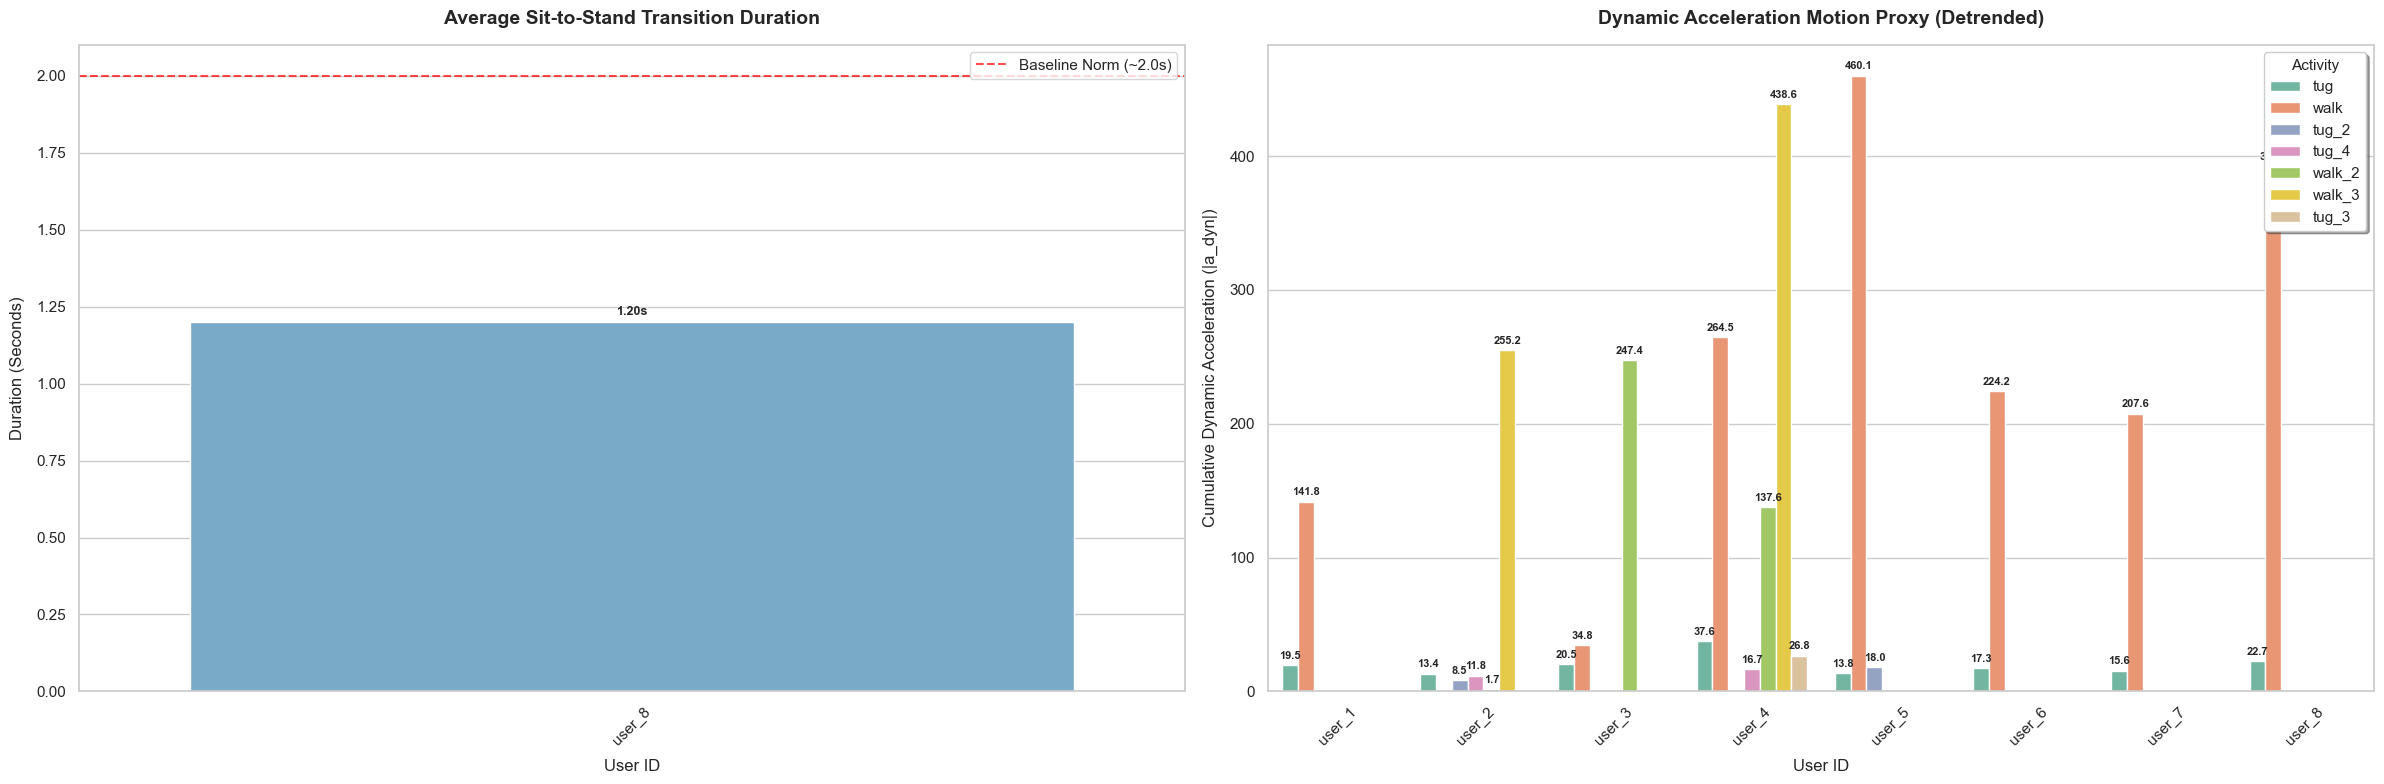

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SAMPLING_RATE_HZ = 20

# =========================================================================
# 1. DATA PREPARATION & INDEX SANITIZATION
# =========================================================================
# Sort by user and time (if a timestamp column exists) and reset index so integer indexing works
time_col = [c for c in Dataset_A.columns if 'time' in c or 'ms' in c]
if time_col:
    Dataset_A = Dataset_A.sort_values(by=['user_id', time_col[0]]).reset_index(drop=True)
else:
    Dataset_A = Dataset_A.reset_index(drop=True)

# Clean activity strings
Dataset_A['activity_clean'] = Dataset_A['activity'].astype(str).str.strip().str.lower()

# Dynamic sensor axis detection
def detect_sensor_axes(df, preferred_node="knee"):
    for node in [preferred_node, "thigh", "lumbar"]:
        cols = [f"{node}_ax", f"{node}_ay", f"{node}_az"]
        if all(c in df.columns for c in cols):
            return cols
    raise KeyError("Could not find expected sensor columns (e.g., knee_ax, knee_ay, knee_az).")

ax_col, ay_col, az_col = detect_sensor_axes(Dataset_A, preferred_node="knee")

# =========================================================================
# 2. SIT-TO-STAND TRANSITION DURATION ANALYSIS (ROBUST)
# =========================================================================
# Compute 3D Acceleration Magnitude & Rolling Motion Envelope
Dataset_A['accel_mag'] = np.sqrt(Dataset_A[ax_col]**2 + Dataset_A[ay_col]**2 + Dataset_A[az_col]**2)
Dataset_A['motion_variance'] = Dataset_A['accel_mag'].rolling(window=10, center=True).var().fillna(0)

# Flexible label normalization (matches 'sit', 'sitting', 'stand', 'standing')
is_sit = Dataset_A['activity_clean'].str.contains('sit')
is_stand = Dataset_A['activity_clean'].str.contains('walk')

# Detect boundary where activity transitions from sit -> stand within the same user
Dataset_A['prev_is_sit'] = is_sit.groupby(Dataset_A['user_id']).shift(1)
transition_mask = (Dataset_A['prev_is_sit'] == True) & (is_stand == True)
transition_indices = Dataset_A[transition_mask].index

print(f"[DEBUG] Detected {len(transition_indices)} potential sit-to-stand boundary points.")

window_samples = 3 * SAMPLING_RATE_HZ  # +/- 3 seconds
transition_records = []

for idx in transition_indices:
    user_id = Dataset_A.loc[idx, 'user_id']
    
    # Define positional search window
    start_win = max(0, idx - window_samples)
    end_win = min(len(Dataset_A) - 1, idx + window_samples)
    
    window_df = Dataset_A.iloc[start_win:end_win + 1]
    
    # Filter active motion using quantile-based dynamic thresholding (falls back if signal is subtle)
    motion_thresh = max(0.02, window_df['motion_variance'].quantile(0.4))
    active_motion = window_df[window_df['motion_variance'] > motion_thresh]

    if not active_motion.empty:
        # Calculate duration based on sample count
        duration_sec = len(active_motion) / SAMPLING_RATE_HZ
        
        # Enforce plausible physical limits
        if 0.3 <= duration_sec <= 8.0:
            transition_records.append({'user_id': user_id, 'duration_seconds': duration_sec})

sit_stand_durations = pd.DataFrame(transition_records)
print(f"[DEBUG] Validated {len(sit_stand_durations)} transition windows for plotting.")

# =========================================================================
# 3. DYNAMIC MOTION / DISTANCE PROXY ANALYSIS
# =========================================================================
rolling_gravity = Dataset_A['accel_mag'].rolling(window=SAMPLING_RATE_HZ, min_periods=1, center=True).mean()
Dataset_A['dynamic_accel_mag'] = (Dataset_A['accel_mag'] - rolling_gravity).abs()

dynamic_mask = Dataset_A['activity_clean'].str.contains('walk|tug|jog')
distance_proxy_df = (
    Dataset_A[dynamic_mask]
    .groupby(['user_id', 'activity_clean'])['dynamic_accel_mag']
    .agg(cumulative_dynamic_accel='sum')
    .reset_index()
)

# =========================================================================
# 4. PLOTTING GENERATION
# =========================================================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(24, 8))

# Plot A: Sit-to-Stand Duration
if not sit_stand_durations.empty:
    sns.barplot(
        ax=axes[0],
        data=sit_stand_durations,
        x='user_id',
        y='duration_seconds',
        hue='user_id',
        palette='Blues_r',
        estimator='mean',
        errorbar=None,
        legend=False
    )
    for container in axes[0].containers:
        axes[0].bar_label(container, fmt="%.2fs", padding=3, fontsize=9, fontweight="semibold")
    axes[0].axhline(2.0, color="red", linestyle="--", alpha=0.7, label="Baseline Norm (~2.0s)")
    axes[0].legend(loc="upper right", frameon=True)
else:
    axes[0].text(0.5, 0.5, "No valid Sit-to-Stand transitions detected.\nCheck activity label names.", 
                 ha='center', va='center', fontsize=12, color='red', transform=axes[0].transAxes)

axes[0].set_title("Average Sit-to-Stand Transition Duration", fontsize=14, fontweight="bold", pad=15)
axes[0].set_xlabel("User ID", fontsize=12, labelpad=8)
axes[0].set_ylabel("Duration (Seconds)", fontsize=12, labelpad=8)
axes[0].tick_params(axis="x", rotation=45)

# Plot B: Dynamic Acceleration Motion Proxy
if not distance_proxy_df.empty:
    sns.barplot(
        ax=axes[1],
        data=distance_proxy_df,
        x='user_id',
        y='cumulative_dynamic_accel',
        hue='activity_clean',
        palette='Set2'
    )
    for container in axes[1].containers:
        axes[1].bar_label(container, fmt="%.1f", padding=3, fontsize=8, fontweight="semibold")

axes[1].set_title("Dynamic Acceleration Motion Proxy (Detrended)", fontsize=14, fontweight="bold", pad=15)
axes[1].set_xlabel("User ID", fontsize=12, labelpad=8)
axes[1].set_ylabel("Cumulative Dynamic Acceleration (|a_dyn|)", fontsize=12, labelpad=8)
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(title="Activity", title_fontsize="11", loc="upper right", frameon=True, shadow=True)

plt.tight_layout()
plt.show()

Population-level analysis of sit-to-stand times, and distances covered while walking and joging

=== POPULATION AVERAGE METRICS ===
Average Sit-to-Stand Duration : 1.20 seconds
Average TUG Motion Proxy : 20.0 units
Average TUG_2 Motion Proxy : 13.2 units
Average TUG_3 Motion Proxy : 26.8 units
Average TUG_4 Motion Proxy : 14.2 units
Average WALK Motion Proxy : 246.5 units
Average WALK_2 Motion Proxy : 128.9 units
Average WALK_3 Motion Proxy : 346.9 units


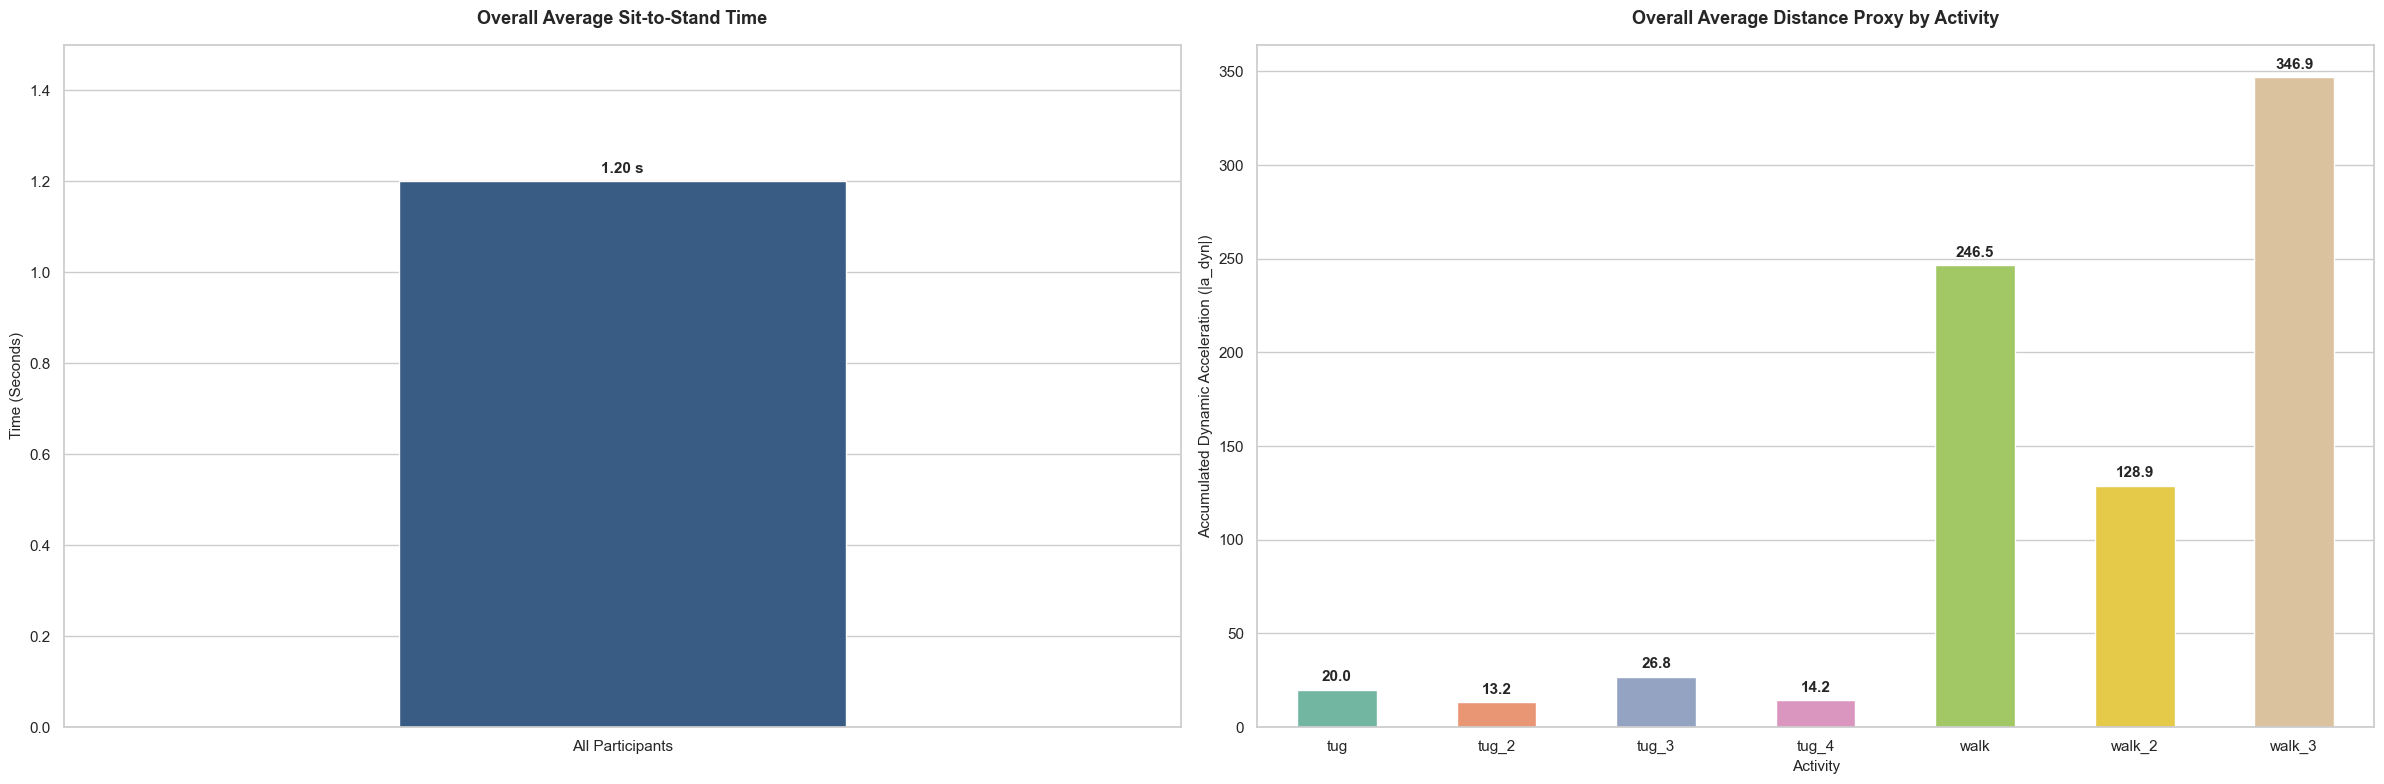

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================================
# 1. POPULATION-LEVEL SUMMARY CALCULATIONS
# =========================================================================
# 1. Average Sit-to-Stand Duration across all participants
if 'sit_stand_durations' in locals() and not sit_stand_durations.empty:
    avg_sit_stand_time = sit_stand_durations['duration_seconds'].mean()
    max_sit_stand_time = sit_stand_durations['duration_seconds'].max()
else:
    avg_sit_stand_time = 0.0
    max_sit_stand_time = 2.0

# 2. Dynamic aggregation of distance proxy metrics across dynamic activities ('walk', 'tug', etc.)
if 'distance_proxy_df' in locals() and not distance_proxy_df.empty:
    dist_summary_df = (
        distance_proxy_df
        .groupby('activity_clean')['cumulative_dynamic_accel']
        .mean()
        .reset_index()
        .rename(columns={
            'activity_clean': 'Activity',
            'cumulative_dynamic_accel': 'Avg_Distance_Proxy'
        })
    )
else:
    dist_summary_df = pd.DataFrame(columns=['Activity', 'Avg_Distance_Proxy'])

# Display numerical summary in console
print("=== POPULATION AVERAGE METRICS ===")
print(f"Average Sit-to-Stand Duration : {avg_sit_stand_time:.2f} seconds")

if not dist_summary_df.empty:
    for _, row in dist_summary_df.iterrows():
        print(f"Average {row['Activity'].upper()} Motion Proxy : {row['Avg_Distance_Proxy']:,.1f} units")
else:
    print("No dynamic activity motion data available.")

# =========================================================================
# 2. POPULATION VISUALIZATION GENERATION
# =========================================================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(24, 8))

# --- Plot 1: Overall Average Sit-to-Stand Duration ---
if avg_sit_stand_time > 0:
    sns.barplot(
        ax=axes[0],
        x=['All Participants'],
        y=[avg_sit_stand_time],
        hue=['All Participants'],  # Prevents Seaborn 0.13+ palette warnings
        palette=['#2b5c8f'],
        width=0.4,
        legend=False
    )
    axes[0].set_ylim(0, max(max_sit_stand_time, avg_sit_stand_time) * 1.25)
    
    # Annotate bar top cleanly using bar_label
    for container in axes[0].containers:
        axes[0].bar_label(container, fmt="%.2f s", padding=4, fontsize=11, fontweight='bold')
else:
    axes[0].text(0.5, 0.5, "No valid Sit-to-Stand data", ha='center', va='center', transform=axes[0].transAxes)

axes[0].set_title('Overall Average Sit-to-Stand Time', fontsize=13, fontweight='bold', pad=15)
axes[0].set_ylabel('Time (Seconds)', fontsize=11)

# --- Plot 2: Overall Average Distance Proxy by Activity ---
if not dist_summary_df.empty:
    sns.barplot(
        ax=axes[1],
        data=dist_summary_df,
        x='Activity',
        y='Avg_Distance_Proxy',
        hue='Activity',
        palette='Set2',
        width=0.5,
        legend=False
    )
    
    # Annotate bar tops with clean metric values
    for container in axes[1].containers:
        axes[1].bar_label(container, fmt="%.1f", padding=4, fontsize=11, fontweight='bold')
else:
    axes[1].text(0.5, 0.5, "No dynamic activity data", ha='center', va='center', transform=axes[1].transAxes)

axes[1].set_title('Overall Average Distance Proxy by Activity', fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('Activity', fontsize=11)
axes[1].set_ylabel('Accumulated Dynamic Acceleration (|a_dyn|)', fontsize=11)

plt.tight_layout()
plt.show()

##### Time Series Segmentation
---

In [ ]:
import numpy as np
import pandas as pd

def create_har_segments(
    df,
    feature_cols,
    window_size=TIME_STEPS,
    hop_size=HOP_SIZE,
    user_col="user_id",
    activity_col="activity"
):
    """
    Creates HAR windows from contiguous activity sessions.

    Returns
    -------
    X : np.ndarray
        Shape:
        (number_of_windows, window_size, number_of_features)

    y : np.ndarray
        Activity label for each window.

    groups : np.ndarray
        User ID corresponding to each window.

    session_ids : np.ndarray
        Contiguous session ID corresponding to each window.
    """

    data = df.copy()

    # -----------------------------------------------------------------------
    # VALIDATION
    # -----------------------------------------------------------------------

    required_cols = (
        [user_col, activity_col]
        +
        list(feature_cols)
    )

    missing_cols = [
        col
        for col in required_cols
        if col not in data.columns
    ]

    if missing_cols:
        raise ValueError(
            f"Missing required columns: {missing_cols}"
        )

    # -----------------------------------------------------------------------
    # SORT CHRONOLOGICALLY
    # -----------------------------------------------------------------------

    time_candidates = [
        "pc_timestamp",
        "timestamp",
        "arduino_ms",
        "arduiono_ms"
    ]

    time_col = next(
        (
            col
            for col in time_candidates
            if col in data.columns
        ),
        None
    )

    sort_cols = [user_col]

    if time_col is not None:
        sort_cols.append(time_col)

    data = (
        data
        .sort_values(sort_cols)
        .reset_index(drop=True)
    )

    # -----------------------------------------------------------------------
    # CLEAN ACTIVITY LABELS
    # -----------------------------------------------------------------------

    data["_activity_clean"] = (
        data[activity_col]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    # -----------------------------------------------------------------------
    # CREATE CONTIGUOUS SESSION IDS
    #
    # A new session begins whenever:
    #   1. User changes
    #   2. Activity changes
    # -----------------------------------------------------------------------

    data["_session_id"] = (
        (data[user_col] != data[user_col].shift())
        |
        (
            data["_activity_clean"]
            !=
            data["_activity_clean"].shift()
        )
    ).cumsum()

    # -----------------------------------------------------------------------
    # CREATE WINDOWS
    # -----------------------------------------------------------------------

    segments = []

    labels = []

    groups = []

    session_ids = []

    for session_id, session_df in data.groupby(
        "_session_id",
        sort=False
    ):

        session_label = (
            session_df["_activity_clean"]
            .iloc[0]
        )

        session_user = (
            session_df[user_col]
            .iloc[0]
        )

        sensor_matrix = (
            session_df[feature_cols]
            .apply(pd.to_numeric, errors="coerce")
            .to_numpy(dtype=np.float32)
        )

        # Remove rows containing NaN values
        valid_rows = ~np.isnan(sensor_matrix).any(axis=1)

        sensor_matrix = sensor_matrix[valid_rows]

        if len(sensor_matrix) < window_size:
            continue

        for start_idx in range(
            0,
            len(sensor_matrix) - window_size + 1,
            hop_size
        ):

            end_idx = start_idx + window_size

            window = sensor_matrix[
                start_idx:end_idx
            ]

            segments.append(window)

            labels.append(session_label)

            groups.append(session_user)

            session_ids.append(session_id)

    # -----------------------------------------------------------------------
    # CONVERT TO ARRAYS
    # -----------------------------------------------------------------------

    X = np.asarray(
        segments,
        dtype=np.float32
    )

    y = np.asarray(labels)

    groups = np.asarray(groups)

    session_ids = np.asarray(session_ids)

    print("=" * 70)

    print("HAR SEGMENTATION COMPLETE")

    print("=" * 70)

    print(f"Sampling Rate       : {SAMPLING_RATE_HZ} Hz")
    print(f"Window Size         : {window_size} samples")
    print(
        f"Window Duration     : "
        f"{window_size / SAMPLING_RATE_HZ:.2f} seconds"
    )
    print(f"Hop Size            : {hop_size} samples")

    print(f"Generated Windows   : {len(X)}")

    if len(X) > 0:

        print(f"X Shape             : {X.shape}")

        print(
            f"Unique Activities   : "
            f"{len(np.unique(y))}"
        )

        print(
            f"Unique Users        : "
            f"{len(np.unique(groups))}"
        )

    print("=" * 70)

    return X, y, groups, session_ids

In [ ]:
# try to figure what's going on here

RAW_SENSOR_FEATURES = [

    # -----------------------------------------------------------------------
    # KNEE IMU
    # -----------------------------------------------------------------------

    "knee_ax",
    "knee_ay",
    "knee_az",

    "knee_gx",
    "knee_gy",
    "knee_gz",

    # -----------------------------------------------------------------------
    # THIGH IMU
    # -----------------------------------------------------------------------

    "thigh_ax",
    "thigh_ay",
    "thigh_az",

    "thigh_gx",
    "thigh_gy",
    "thigh_gz",

    # -----------------------------------------------------------------------
    # LUMBAR IMU
    # -----------------------------------------------------------------------

    "lumbar_ax",
    "lumbar_ay",
    "lumbar_az",

    "lumbar_gx",
    "lumbar_gy",
    "lumbar_gz"
]


# Keep only columns that actually exist
SENSOR_FEATURES = [
    col
    for col in RAW_SENSOR_FEATURES
    if col in Dataset_features.columns
]

print("Sensor Features Used:")
print(SENSOR_FEATURES)

print(f"\nNumber of Sensor Channels: {len(SENSOR_FEATURES)}")

Sensor Features Used:
['knee_ax', 'knee_ay', 'knee_az', 'knee_gx', 'knee_gy', 'knee_gz', 'thigh_ax', 'thigh_ay', 'thigh_az', 'thigh_gx', 'thigh_gy', 'thigh_gz', 'lumbar_ax', 'lumbar_ay', 'lumbar_az', 'lumbar_gx', 'lumbar_gy', 'lumbar_gz']

Number of Sensor Channels: 18


##### Regression Segments and Models 
---

In [ ]:
import numpy as np
import pandas as pd

def create_regression_segments_and_features(
    df: pd.DataFrame, 
    window_size: int = 60, 
    sampling_rate_hz: int = 20,
    preferred_node: str = "knee"
):
    """
    Finds sit-to-stand transitions in Dataset_A, extracts a centered temporal block 
    around each event, computes summary statistical features across sensor channels,
    and returns feature matrix X, target durations y, and subject groups (user_ids).
    """
    # 1. Reset index and sanitize dataset
    data = df.copy().reset_index(drop=True)
    data["activity_clean"] = data["activity"].astype(str).str.strip().str.lower()
    
    # 2. Dynamic sensor channel selection
    exclude_cols = {'user_id', 'activity', 'activity_clean', 'prev_activity', 'prev_is_sit'}
    signal_cols = [
        col for col in data.columns 
        if col not in exclude_cols 
        and not any(k in col for k in ['time', 'ms', 'sec', 'index', 'transition'])
        and pd.api.types.is_numeric_dtype(data[col])
    ]
    
    # Ensure magnitude & motion variance exist for primary sensor node
    ax_col, ay_col, az_col = f"{preferred_node}_ax", f"{preferred_node}_ay", f"{preferred_node}_az"
    if all(c in data.columns for c in [ax_col, ay_col, az_col]):
        if "accel_mag" not in data.columns:
            data["accel_mag"] = np.sqrt(data[ax_col]**2 + data[ay_col]**2 + data[az_col]**2)
        if "motion_variance" not in data.columns:
            half_sec = max(3, sampling_rate_hz // 2)
            data["motion_variance"] = data["accel_mag"].rolling(window=half_sec, center=True).var().fillna(0)
            
        if "accel_mag" not in signal_cols:
            signal_cols.append("accel_mag")
        if "motion_variance" not in signal_cols:
            signal_cols.append("motion_variance")

    # 3. Detect Sit-to-Stand transition boundaries per user
    is_sit = data["activity_clean"].str.contains("sit")
    is_stand = data["activity_clean"].str.contains("stand")
    data["prev_is_sit"] = is_sit.groupby(data["user_id"]).shift(1)
    
    transition_mask = (data["prev_is_sit"] == True) & (is_stand == True)
    transition_indices = data[transition_mask].index

    features_list = []
    targets_list = []
    groups_list = []  # Track user_id for GroupKFold
    half_window = window_size // 2

    # 4. Extract centered block around each transition event
    for idx in transition_indices:
        user_id = data.loc[idx, "user_id"]
        
        # Positional slicing window around transition
        start_idx = max(0, idx - half_window)
        end_idx = min(len(data) - 1, idx + half_window)
        
        block = data.iloc[start_idx : end_idx + 1]
        
        # Determine target sit-to-stand duration (y) from motion variance envelope
        if "motion_variance" in block.columns:
            motion_thresh = max(0.02, block["motion_variance"].quantile(0.4))
            active_motion = block[block["motion_variance"] > motion_thresh]
            
            if not active_motion.empty:
                duration_sec = len(active_motion) / sampling_rate_hz
            else:
                duration_sec = len(block) / sampling_rate_hz
        else:
            duration_sec = len(block) / sampling_rate_hz
            
        # Physiological filter constraint
        if not (0.3 <= duration_sec <= 8.0):
            continue

        # 5. Calculate block summary statistical features
        block_features = {}
        for col in signal_cols:
            series = block[col]
            block_features[f"{col}_mean"] = series.mean()
            block_features[f"{col}_std"] = series.std()
            block_features[f"{col}_min"] = series.min()
            block_features[f"{col}_max"] = series.max()
            block_features[f"{col}_range"] = series.max() - series.min()
            block_features[f"{col}_rms"] = np.sqrt(np.mean(series**2))
            
        features_list.append(block_features)
        targets_list.append(duration_sec)
        groups_list.append(user_id)  # Store corresponding participant ID

    X = pd.DataFrame(features_list)
    y = np.array(targets_list)
    groups = np.array(groups_list)

    print(f"Regression Dataset Generation Complete:")
    print(f"  - Features Matrix (X) Shape : {X.shape}")
    print(f"  - Target Array (y) Shape     : {y.shape}")
    print(f"  - User Groups Array Shape    : {groups.shape} ({len(np.unique(groups))} unique subjects)")

    return X, y, groups

# =========================================================================
# EXECUTION
# =========================================================================
X, y, groups = create_regression_segments_and_features(Dataset_A, window_size=60)

Regression Dataset Generation Complete:
  - Features Matrix (X) Shape : (2, 162)
  - Target Array (y) Shape     : (2,)
  - User Groups Array Shape    : (2,) (2 unique subjects)


##### Time Taken to Switch Activities

Because our dataset lacks explicit "transition" labels (the data instantly switches from "Sitting" to "Standing"), calculating transition times requires a bit of clever engineering.If we rely purely on the label boundary, the transition time would always be exactly 1 sample interval (e.g., $1 / 20\text{ Hz} = 0.05\text{ seconds}$), which is physically meaningless.To solve this, we can use a sensor-driven heuristic approach. When a person transitions (e.g., sits to stands, or sits to walks), their acceleration goes from perfectly static (low variance) to a dynamic spike (high variance), and then back to a stable state.By analyzing a small window of sensor data around the exact moment the label switches, we can calculate the physical transition duration based on when the body was actually in motion.

In [ ]:
import numpy as np
import pandas as pd

def calculate_transition_durations(
    sensor_dataframe: pd.DataFrame, 
    target_node: str = "knee",
    sampling_rate_hz: int = 20,
    window_seconds: int = 3
) -> pd.DataFrame:
    """
    Detects boundaries between consecutive activity sessions for each user 
    (e.g., sit -> stand, stand -> walk) and measures physical movement duration 
    around boundary points using acceleration variance.
    """
    # Reset index to guarantee clean contiguous integer indexing for .loc[idx - 1]
    df = sensor_dataframe.copy().reset_index(drop=True)
    
    # Derive node-specific column names (e.g., knee_ax, knee_ay, knee_az)
    ax_col = f"{target_node}_ax"
    ay_col = f"{target_node}_ay"
    az_col = f"{target_node}_az"
    
    if not all(col in df.columns for col in [ax_col, ay_col, az_col]):
        raise KeyError(f"Target node columns ('{ax_col}', '{ay_col}', '{az_col}') not found in DataFrame.")

    # 1. Compute 3D acceleration magnitude for the target node
    accel_magnitude = np.sqrt(df[ax_col]**2 + df[ay_col]**2 + df[az_col]**2)
        
    # 2. Calculate rolling variance to quantify physical movement spikes
    half_second_window = max(3, sampling_rate_hz // 2)
    df["accel_variance"] = accel_magnitude.rolling(window=half_second_window, center=True).var().fillna(0)

    # 3. Initialize duration tracking columns matching your dataset's activity types
    transition_cols = ["sit_stand_time", "stand_walk_time", "sit_walk_time", "stand_tug_time"]
    for col in transition_cols:
        df[col] = 0.0

    # 4. Identify boundary row indices where activity changes for the SAME user
    is_new_activity = df["activity"] != df["activity"].shift()
    is_same_user = df["user_id"] == df["user_id"].shift()

    # transition_indices holds row indices where a new activity begins for the user
    transition_indices = df[is_new_activity & is_same_user].index

    # 5. Map transition pairs using current dataset labels ('sit', 'stand', 'walk', 'tug')
    target_transitions = {
        ("sit", "stand"): "sit_stand_time",
        ("stand", "walk"): "stand_walk_time",
        ("sit", "walk"): "sit_walk_time",
        ("stand", "tug"): "stand_tug_time"
    }

    window_samples = window_seconds * sampling_rate_hz

    # 6. Analyze signal variance around boundary points
    for idx in transition_indices:
        prev_activity = str(df.loc[idx - 1, "activity"]).strip().lower()
        next_activity = str(df.loc[idx, "activity"]).strip().lower()
        transition_pair = (prev_activity, next_activity)

        if transition_pair in target_transitions:
            target_column = target_transitions[transition_pair]

            # Define search window around the boundary row index
            start_win = max(0, idx - window_samples)
            end_win = min(len(df) - 1, idx + window_samples)
            window_data = df.loc[start_win:end_win]

            # Filter for samples exceeding movement noise threshold
            movement_threshold = 0.08 
            moving_samples = window_data[window_data["accel_variance"] > movement_threshold]

            if len(moving_samples) > 0:
                first_movement_idx = moving_samples.index.min()
                last_movement_idx = moving_samples.index.max()
                
                duration_samples = (last_movement_idx - first_movement_idx) + 1
                duration_seconds = duration_samples / sampling_rate_hz
                
                # Assign calculated duration to the boundary start row
                df.loc[idx, target_column] = duration_seconds

    # Clean up temporary helper column
    df.drop(columns=["accel_variance"], inplace=True)
    return df

# Execute directly on master dataset
Dataset_A = calculate_transition_durations(Dataset_A, target_node="knee", sampling_rate_hz=20)
Dataset_A.head()

,pc_timestamp,knee_ax,knee_ay,knee_az,knee_gx,knee_gy,knee_gz,lumbar_ax,lumbar_ay,lumbar_az,...,downstairs_duration,activity_clean,accel_mag,motion_variance,prev_is_sit,dynamic_accel_mag,sit_stand_time,stand_walk_time,sit_walk_time,stand_tug_time
0,1970-01-01 00:29:46.634352849,0.286942,-0.918417,-0.244490,1.19,-4.06,-0.98,-0.027328,0.979904,-0.241560,...,0.0,stand,0.992774,0.0,NaN,0.001921,0.0,0.0,0.0,0.0
1,1970-01-01 00:29:46.634352849,0.287089,-0.919714,-0.242854,1.05,-4.06,-1.05,-0.027375,0.979858,-0.241551,...,0.0,stand,0.993615,0.0,False,0.001107,0.0,0.0,0.0,0.0
2,1970-01-01 00:29:46.634352849,0.287807,-0.920103,-0.242446,1.05,-4.27,-1.19,-0.027391,0.979842,-0.241548,...,0.0,stand,0.994084,0.0,False,0.000744,0.0,0.0,0.0,0.0
3,1970-01-01 00:29:46.634352849,0.288643,-0.919869,-0.243391,1.05,-4.48,-1.12,-0.027321,0.979910,-0.241561,...,0.0,stand,0.994340,0.0,False,0.000626,0.0,0.0,0.0,0.0
4,1970-01-01 00:29:46.634352849,0.288724,-0.919965,-0.245012,0.91,-4.34,-1.12,-0.027194,0.980035,-0.241585,...,0.0,stand,0.994851,0.0,False,0.000204,0.0,0.0,0.0,0.0


Label-encode the activity column

In [ ]:
label_encoder = LabelEncoder()
label_encoder.fit(Dataset_A['activity'])
Dataset_A['activity'] = label_encoder.transform(Dataset_A['activity'])
Dataset_A.head()

,pc_timestamp,knee_ax,knee_ay,knee_az,knee_gx,knee_gy,knee_gz,lumbar_ax,lumbar_ay,lumbar_az,...,downstairs_duration,activity_clean,accel_mag,motion_variance,prev_is_sit,dynamic_accel_mag,sit_stand_time,stand_walk_time,sit_walk_time,stand_tug_time
0,1970-01-01 00:29:46.634352849,0.286942,-0.918417,-0.244490,1.19,-4.06,-0.98,-0.027328,0.979904,-0.241560,...,0.0,stand,0.992774,0.0,NaN,0.001921,0.0,0.0,0.0,0.0
1,1970-01-01 00:29:46.634352849,0.287089,-0.919714,-0.242854,1.05,-4.06,-1.05,-0.027375,0.979858,-0.241551,...,0.0,stand,0.993615,0.0,False,0.001107,0.0,0.0,0.0,0.0
2,1970-01-01 00:29:46.634352849,0.287807,-0.920103,-0.242446,1.05,-4.27,-1.19,-0.027391,0.979842,-0.241548,...,0.0,stand,0.994084,0.0,False,0.000744,0.0,0.0,0.0,0.0
3,1970-01-01 00:29:46.634352849,0.288643,-0.919869,-0.243391,1.05,-4.48,-1.12,-0.027321,0.979910,-0.241561,...,0.0,stand,0.994340,0.0,False,0.000626,0.0,0.0,0.0,0.0
4,1970-01-01 00:29:46.634352849,0.288724,-0.919965,-0.245012,0.91,-4.34,-1.12,-0.027194,0.980035,-0.241585,...,0.0,stand,0.994851,0.0,False,0.000204,0.0,0.0,0.0,0.0


Normalizating The Dataset

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Dynamically select ONLY numeric columns, ignoring string/object metadata
numeric_cols = Dataset_A.select_dtypes(include=[np.number]).columns.tolist()

# 2. Exclude non-feature ID or time index columns
ignore_cols = ['user_id', 'pc_timestamp', 'arduiono_ms', 'rssi', 'is_step_detected']
feature_cols = [col for col in numeric_cols if col not in ignore_cols]

# 3. Create a separate scaled DataFrame or append scaled columns
scaler = StandardScaler()
scaled_features = pd.DataFrame(
    scaler.fit_transform(Dataset_A[feature_cols]),
    columns=[f"{col}_scaled" for col in feature_cols],
    index=Dataset_A.index
)

# Merge back without corrupting original raw columns
Dataset_A_scaled = pd.concat([Dataset_A, scaled_features], axis=1)

In [ ]:
# drop NA Values
# Dataset_A_scaled.dropna(inplace=True)

In [ ]:
print_horizontal_line()
print_horizontal_line()


-- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- 
-- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- 

---
#### Modelling
---

predict sit-stand time

In [ ]:
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    precision_recall_fscore_support
)

from sklearn.model_selection import GroupShuffleSplit

from sklearn.preprocessing import LabelEncoder


# ============================================================================
# 1. CREATE HAR WINDOWS
# ============================================================================

X_signals, y_labels, window_users, window_sessions = (
    create_har_segments(
        df=Dataset_features,
        feature_cols=SENSOR_FEATURES,
        window_size=TIME_STEPS,
        hop_size=HOP_SIZE
    )
)


if len(X_signals) == 0:
    raise ValueError(
        "No HAR windows were generated. "
        "Check activity session lengths and feature columns."
    )


# ============================================================================
# 2. ENCODE ACTIVITY LABELS
# ============================================================================

har_label_encoder = LabelEncoder()

y_encoded = har_label_encoder.fit_transform(
    y_labels
)

print("\nActivity Mapping:")

for index, activity in enumerate(
    har_label_encoder.classes_
):
    print(
        f"{activity} -> {index}"
    )


# ============================================================================
# 3. PARTICIPANT-WISE TRAIN / TEST SPLIT
# ============================================================================

unique_users = np.unique(
    window_users
)

if len(unique_users) < 2:

    raise ValueError(
        "Participant-wise evaluation requires at least "
        "2 unique users."
    )


gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_SEED
)


train_idx, test_idx = next(
    gss.split(
        X_signals,
        y_encoded,
        groups=window_users
    )
)


X_rf_train_signals = X_signals[train_idx]

X_rf_test_signals = X_signals[test_idx]

y_rf_train = y_encoded[train_idx]

y_rf_test = y_encoded[test_idx]


print("\nParticipant Split")

print("-" * 60)

print(
    "Training Users:",
    np.unique(window_users[train_idx])
)

print(
    "Testing Users:",
    np.unique(window_users[test_idx])
)


# ============================================================================
# 4. CONVERT TIME SERIES WINDOWS TO STATISTICAL FEATURES
# ============================================================================

def extract_statistical_features(X):
    """
    Converts 3D HAR windows:

        (samples, time_steps, channels)

    into statistical feature vectors.
    """

    feature_vectors = []

    for window in X:

        feature_vector = np.concatenate([

            np.mean(window, axis=0),

            np.std(window, axis=0),

            np.min(window, axis=0),

            np.max(window, axis=0),

            np.median(window, axis=0),

            np.sqrt(
                np.mean(
                    window ** 2,
                    axis=0
                )
            )

        ])

        feature_vectors.append(
            feature_vector
        )

    return np.asarray(
        feature_vectors,
        dtype=np.float32
    )


X_rf_train = extract_statistical_features(
    X_rf_train_signals
)

X_rf_test = extract_statistical_features(
    X_rf_test_signals
)


print("\nRandom Forest Input")

print(f"X_train: {X_rf_train.shape}")

print(f"X_test : {X_rf_test.shape}")


# ============================================================================
# 5. TRAIN RANDOM FOREST
# ============================================================================

rf_model = RandomForestClassifier(

    n_estimators=300,

    random_state=RANDOM_SEED,

    n_jobs=-1,

    class_weight="balanced"
)


rf_model.fit(
    X_rf_train,
    y_rf_train
)


# ============================================================================
# 6. EVALUATE RANDOM FOREST
# ============================================================================

rf_predictions = rf_model.predict(
    X_rf_test
)


rf_accuracy = accuracy_score(
    y_rf_test,
    rf_predictions
)


rf_precision, rf_recall, rf_f1, _ = (
    precision_recall_fscore_support(
        y_rf_test,
        rf_predictions,
        average="macro",
        zero_division=0
    )
)


print("\n" + "=" * 70)

print("RANDOM FOREST RESULTS")

print("=" * 70)

print(
    f"Accuracy : {rf_accuracy:.4f}"
)

print(
    f"Precision: {rf_precision:.4f}"
)

print(
    f"Recall   : {rf_recall:.4f}"
)

print(
    f"F1 Score : {rf_f1:.4f}"
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_rf_test,
        rf_predictions,
        target_names=har_label_encoder.classes_,
        zero_division=0
    )
)

HAR SEGMENTATION COMPLETE
Sampling Rate       : 20 Hz
Window Size         : 100 samples
Window Duration     : 5.00 seconds
Hop Size            : 50 samples
Generated Windows   : 1878
X Shape             : (1878, 100, 18)
Unique Activities   : 9
Unique Users        : 8

Activity Mapping:
sit -> 0
stand -> 1
tug -> 2
tug_2 -> 3
tug_3 -> 4
tug_4 -> 5
walk -> 6
walk_2 -> 7
walk_3 -> 8

Participant Split
------------------------------------------------------------
Training Users: ['user_1' 'user_3' 'user_4' 'user_5' 'user_7' 'user_8']
Testing Users: ['user_2' 'user_6']

Random Forest Input
X_train: (1420, 108)
X_test : (458, 108)

RANDOM FOREST RESULTS
Accuracy : 0.6245
Precision: 0.3030
Recall   : 0.3897
F1 Score : 0.3083

Classification Report:



ValueError: Number of classes, 8, does not match size of target_names, 9. Try specifying the labels parameter

Split data into train, test and Validation Sets (User-based splitting to avoid data leakage)

In [ ]:
# Extract unique users and shuffle/slice them deterministically
unique_users = Dataset_A['user_id'].unique()

train_users = unique_users[:30]
val_users = unique_users[30:33]
test_users = unique_users[33:]

# Filter the DataFrames based on the user groups
train_df = Dataset_A[Dataset_A['user_id'].isin(train_users)]
val_df = Dataset_A[Dataset_A['user_id'].isin(val_users)]
test_df = Dataset_A[Dataset_A['user_id'].isin(test_users)]

# Generate 3D windows for all three subsets
X_train_3d, y_train_strings = create_segments_and_labels(train_df)
X_val_3d, y_val_strings = create_segments_and_labels(val_df)
X_test_3d, y_test_strings = create_segments_and_labels(test_df)

# Fit the LabelEncoder on the training set and transform all targets
le = LabelEncoder()
y_train = le.fit_transform(y_train_strings)
y_val = le.transform(y_val_strings)
y_test = le.transform(y_test_strings)

print_horizontal_line()
print(le.classes_)
print_horizontal_line()

# Print out shapes to verify the distribution
print(f"Train shapes:      X Train = {X_train_3d.shape}, y = {y_train.shape}")
print(f"Validation shapes: X Val = {X_val_3d.shape}, y = {y_val.shape}")
print(f"Test shapes:       X Test = {X_test_3d.shape}, y = {y_test.shape}")

Training LSTM and CNN

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. ENCODE TARGET LABELS & PREPARE FEATURE COLUMNS
label_encoder = LabelEncoder()
Dataset_A["activity_encoded"] = label_encoder.fit_transform(Dataset_A["activity"])

# Exclude metadata and label columns to isolate sensor features
non_feature_cols = [
    "user_id", "activity", "activity_encoded", 
    "pc_timestamp", "arduiono_ms", "rssi"
]
feature_cols = [col for col in Dataset_A.columns if col not in non_feature_cols]

# Ensure numerical conversion and handle missing values across feature columns
for col in feature_cols:
    Dataset_A[col] = pd.to_numeric(Dataset_A[col], errors="coerce")
Dataset_A.dropna(subset=feature_cols, inplace=True)

# 2. GROUPED SLIDING WINDOW & STATISTICAL FEATURE EXTRACTION
TIME_STEPS = 100  # 5 seconds at 20Hz
STEP = 50         # 50% overlap for data augmentation

X_features = []
y_labels = []

# Group by (user_id, activity_encoded) to prevent windows from spanning across sessions
for (user_id, act_code), group_df in Dataset_A.groupby(["user_id", "activity_encoded"]):
    sensor_matrix = group_df[feature_cols].values
    
    # Skip sessions shorter than the required window size
    if len(sensor_matrix) < TIME_STEPS:
        continue

    # Slide window strictly within this session block
    for i in range(0, len(sensor_matrix) - TIME_STEPS + 1, STEP):
        window = sensor_matrix[i : i + TIME_STEPS]  # Shape: (100, num_features)

        # Compute summary statistics across the time axis (axis=0) for ALL sensor features
        win_mean = np.mean(window, axis=0)
        win_std = np.std(window, axis=0)
        win_max = np.max(window, axis=0)
        win_min = np.min(window, axis=0)

        # Concatenate summary statistics into a single feature vector
        window_stats = np.hstack([win_mean, win_std, win_max, win_min])
        
        X_features.append(window_stats)
        y_labels.append(act_code)

# Convert windowed collections to arrays
X_features = np.array(X_features, dtype=np.float32)
y = np.array(y_labels, dtype=np.int32)

# 3. TRAIN / TEST SPLIT & MODEL EVALUATION
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Extracted Windows Count : {X_features.shape[0]}")
print(f"Features per Window     : {X_features.shape[1]}")
print(f"Training set shape      : {X_train.shape}")
print(f"Testing set shape       : {X_test.shape}\n")

print("Training Random Forest Classifier... Please wait...")
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Predict on test set
y_pred = rf_model.predict(X_test)

# Output performance metrics
accuracy = accuracy_score(y_test, y_pred)
print("=" * 60)
print(f"Model Accuracy: {accuracy * 100:.2f}%")
print("=" * 60)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=[str(c) for c in label_encoder.classes_]))

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, LSTM
from tensorflow.keras.utils import to_categorical

# 1. ENCODE TARGET LABELS & DYNAMICALLY EXTRACT ALL SENSOR FEATURES
label_encoder = LabelEncoder()
Dataset_A['activity_encoded'] = label_encoder.fit_transform(Dataset_A['activity'])

# Isolate all continuous sensor and engineered feature channels
non_feature_cols = [
    "user_id", "activity", "activity_encoded", 
    "pc_timestamp", "arduiono_ms", "rssi"
]
feature_cols = [col for col in Dataset_A.columns if col not in non_feature_cols]

# Ensure numerical type conversion and clean NaN values across features
for col in feature_cols:
    Dataset_A[col] = pd.to_numeric(Dataset_A[col], errors='coerce')
Dataset_A.dropna(subset=feature_cols, inplace=True)

num_features = len(feature_cols)
print(f"Total Input Feature Channels: {num_features}")

# 2. SESSION-ISOLATED SLIDING WINDOW CREATION FOR DEEP LEARNING
TIME_STEPS = 100  # 5 seconds at 20Hz
STEP = 50         # 50% overlap for data augmentation

segments = []
labels = []

# Group by (user_id, activity_encoded) to isolate windows within single session blocks
for (user_id, act_code), group_df in Dataset_A.groupby(["user_id", "activity_encoded"]):
    sensor_matrix = group_df[feature_cols].values
    
    # Skip sessions that are shorter than the window requirement
    if len(sensor_matrix) < TIME_STEPS:
        continue

    # Slide window across all feature channels simultaneously
    for i in range(0, len(sensor_matrix) - TIME_STEPS + 1, STEP):
        window = sensor_matrix[i : i + TIME_STEPS]  # Shape: (100, num_features)
        
        segments.append(window)
        labels.append(act_code)

# Convert to 3D NumPy array for Keras/TensorFlow -> Shape: (N_samples, 100, num_features)
X_signals = np.asarray(segments, dtype=np.float32)
y = np.asarray(labels, dtype=np.int32)

# One-hot encode targets for multi-class deep learning output
num_classes = len(np.unique(y))
y_categorical = to_categorical(y, num_classes=num_classes)

# Train-Test Split (maintains stratification across activity classes)
X_train, X_test, y_train, y_test = train_test_split(
    X_signals, y_categorical, test_size=0.2, random_state=42, stratify=y
)

print(f"Training Data Shape (X_train) : {X_train.shape}")  # (N_train, 100, num_features)
print(f"Testing Data Shape (X_test)   : {X_test.shape}")   # (N_test, 100, num_features)
print(f"Number of Target Classes       : {num_classes}\n")

# 3. MODEL 1: Conv1D (CNN)
print("=" * 40)
print("--- Training 1D-CNN Model ---")
print("=" * 40)

cnn_model = Sequential([
    # Input shape dynamically scales to match (TIME_STEPS, num_features)
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(TIME_STEPS, num_features)),
    Conv1D(filters=64, kernel_size=3, activation='relu'),
    Dropout(0.5),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(100, activation='relu'),
    Dense(num_classes, activation='softmax')
])

cnn_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

cnn_history = cnn_model.fit(
    X_train, y_train, 
    epochs=10, 
    batch_size=64, 
    validation_split=0.1, 
    verbose=1
)

# Evaluate CNN
cnn_preds = np.argmax(cnn_model.predict(X_test), axis=1)
y_test_true = np.argmax(y_test, axis=1)
class_names = [str(c) for c in label_encoder.classes_]

print("\n" + "=" * 40 + "\nCNN RESULTS\n" + "=" * 40)
print(f"CNN Accuracy: {accuracy_score(y_test_true, cnn_preds) * 100:.2f}%")
print(classification_report(y_test_true, cnn_preds, target_names=class_names))


# 4. MODEL 2: LSTM
print("\n" + "=" * 40)
print("--- Training LSTM Model ---")
print("=" * 40)

lstm_model = Sequential([
    LSTM(64, input_shape=(TIME_STEPS, num_features), return_sequences=True),
    LSTM(64),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

lstm_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

lstm_history = lstm_model.fit(
    X_train, y_train, 
    epochs=10, 
    batch_size=64, 
    validation_split=0.1, 
    verbose=1
)

# Evaluate LSTM
lstm_preds = np.argmax(lstm_model.predict(X_test), axis=1)

print("\n" + "=" * 40 + "\nLSTM RESULTS\n" + "=" * 40)
print(f"LSTM Accuracy: {accuracy_score(y_test_true, lstm_preds) * 100:.2f}%")
print(classification_report(y_test_true, lstm_preds, target_names=class_names))

##### Visualise Model Performance across the different classes
---

In [ ]:
# create a dataframe of the results from the CNN, LSTM, and Random Forest models for comparison
results_df = pd.DataFrame({
    'Model': ['Random Forest', 'CNN', 'LSTM'],
    'Accuracy': [
        # FIXED: Changed y_test to y_test_true to match y_pred's format
        accuracy_score(y_test_true, y_pred) * 100,
        accuracy_score(y_test_true, cnn_preds) * 100,
        accuracy_score(y_test_true, lstm_preds) * 100
    ]
})

# plot the results in a bar chart
plt.figure(figsize=(16, 4))
# Note: Added hue='Model' and legend=False to comply with modern Seaborn styling requirements
sns.barplot(x='Model', y='Accuracy', data=results_df, palette='viridis', hue='Model', legend=False)
plt.title('Model Comparison: Accuracy of Random Forest, CNN, and LSTM', fontsize=16)
plt.ylabel('Accuracy (%)', fontsize=14)
plt.ylim(0, 100)

# annotate the bars with the accuracy values
for index, row in results_df.iterrows():
    plt.text(index, row.Accuracy + 1, f"{row.Accuracy:.2f}%", color='black', ha="center", fontsize=8)

plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, ELU, MaxPool1D, 
    Bidirectional, GRU, Add, GlobalAveragePooling1D, 
    Dense, Reshape, Multiply
)
from tensorflow.keras.models import Model

def squeeze_and_excitation_block(input_tensor, ratio=16):
    """
    Squeeze-and-Excitation Block for channel-wise feature attention recalibration.
    """
    filters = input_tensor.shape[-1]
    
    # Squeeze phase: Global Average Pooling across the temporal axis
    se = GlobalAveragePooling1D()(input_tensor)
    se = Reshape((1, filters))(se)
    
    # Excitation phase: Two-stage bottleneck dense scaling
    se = Dense(filters // ratio, activation='relu', use_bias=False)(se)
    se = Dense(filters, activation='sigmoid', use_bias=False)(se)
    
    # Scale phase: Weight channels back into the input sequence
    return Multiply()([input_tensor, se])

def convolutional_block_convb(input_tensor, filters, kernel_size=3, pool_size=2):
    """
    ConvB Layer: Extracts spatial/low-level features from sensor sequences.
    Consists of Conv1D -> Batch Normalization -> ELU -> Max Pooling.
    """
    x = Conv1D(filters, kernel_size=kernel_size, padding='same')(input_tensor)
    x = BatchNormalization()(x)
    x = ELU()(x)
    x = MaxPool1D(pool_size=pool_size, padding='same')(x)
    return x

def build_convres_bigru_se(input_shape, num_classes):
    """
    Constructs the complete hybrid ConvResBiGRU-SE network structure.
    """
    inputs = Input(shape=input_shape)
    
    # --- 1. Base Convolutional Feature Extraction (ConvB) ---
    conv_out = convolutional_block_convb(inputs, filters=64, kernel_size=5, pool_size=2)
    
    # --- 2. Temporal Analysis Layer (Bidirectional GRU) ---
    # return_sequences=True keeps the output 3D so it can feed the next structural blocks
    gru_out = Bidirectional(GRU(64, return_sequences=True))(conv_out)
    
    # --- 3. Residual Mapping Integration ---
    # Match spatial and feature dimensions between Conv output and BiGRU output
    shortcut = Conv1D(128, kernel_size=1, padding='same')(conv_out) 
    shortcut = BatchNormalization()(shortcut)
    
    # Residual Skip-Connection Addition
    res_addition = Add()([gru_out, shortcut])
    res_out = ELU()(res_addition)
    
    # --- 4. Squeeze-and-Excitation Recalibration ---
    se_out = squeeze_and_excitation_block(res_out, ratio=16)
    
    # --- 5. Classification Output Head ---
    pooling_layer = GlobalAveragePooling1D()(se_out)
    outputs = Dense(num_classes, activation='softmax')(pooling_layer)
    
    model = Model(inputs, outputs, name="ConvResBiGRU_SE")
    return model

# --- Notebook Integration Config ---
# For WISDM data sampled at 20Hz using a sliding window of 100 timestamps (6.4 seconds)
TIME_STEPS = 100
CHANNELS = 3      # Tri-axial raw sensor data: x, y, z metrics
NUM_CLASSES = 6   # Standard target actions (Walking, Jogging, etc.)

# Instantiate and compile the architecture
model = build_convres_bigru_se(input_shape=(TIME_STEPS, CHANNELS), num_classes=NUM_CLASSES)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

# Train the ConvResBiGRU-SE model
# 1. Compute evaluation metrics from predictions
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1) if len(y_test.shape) > 1 else y_test

accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')

# Train the model to optimize its weights before evaluating it
model.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.2)

# 2. Package metrics into a row DataFrame
new_row = pd.DataFrame([{
    'Model': 'ConvResBiGRU-SE',
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1
}])

# 3. Concatenate safely into results_df
try:
    results_df = pd.concat([results_df, new_row], ignore_index=True)
    results_df.drop_duplicates(subset=['Model'], keep='last', inplace=True)
except NameError:
    results_df = new_row

# Display updated table
display(results_df)

#### Timed-Up-and-Go (TUG)
---
The timed Up and Go (TUG) is a clinical test that evaluates functional mobility and fall risk. It measures the time it takes for a person to stand from a chair, walk threee meters(about 10 feet), turn around, walk back, and sit down again. 

The patient sits comfortably against a chair and rises on the word "Go", walks to a designated three-meter mark at a safe pace, turns around, and returns to seated. 

Equipment used include a standard arm chari, a stopwatch, a floor marker exactly three meters away and any assistive devices (eg walking aids)

Interpreting Results

The total time correlates with mobility and balance:Under 10 seconds: Normal mobility.11–20 seconds: Mostly independent with good functional mobility.Over 12–15 seconds: Often indicates an increased risk of falls and reduced functional independence.Over 30 seconds: Indicates significant mobility issues and a high risk of falling.


so far, we have identified when a person is: 
1. walking
2. sitting
3. standing
4. jogging
5. upstairs
6. downstairs
we have also identified:
1. distance covered during activity

---
### Actual Data Pre-processing Pipeline
---